# Исследование классификации банковских операций и Cash Flow

Ноутбук решает прикладную задачу финансового аудита малого производственного бизнеса: классифицировать банковские операции, собрать управленческий Cash Flow и понять, где бизнес теряет деньги.

Главное изменение этой версии: используем **строгие укрупнённые категории**, которые не пересекаются по смыслу. Детализация вроде «предоплата», «аренда», «проценты», «сгущёнка» теперь живёт в поле `subcategory`, а не плодит новые категории.

## Логика исследования

1. Загружаем и дедуплицируем банковскую выписку.
2. Диагностируем и исправляем даты, чтобы не ломать помесячный Cash Flow.
3. Нормализуем суммы, тип операции, контрагентов и назначения платежа.
4. Классифицируем операции rule-based методом.
5. При наличии LM Studio сравниваем локальную модель с правилами.
6. Собираем итоговую классификацию и причины ручной проверки.
7. Готовим 500 операций для ручной валидации.
8. Пересобираем Cash Flow без внутренних переводов в операционном денежном потоке.
9. Сохраняем результаты и формируем выводы.

In [ ]:
from __future__ import annotations

import json
import re
import warnings
from collections import Counter
from pathlib import Path
from typing import Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import seaborn as sns
    sns.set_theme(style='whitegrid')
except Exception:
    sns = None

from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

pd.set_option('display.max_columns', 120)
pd.set_option('display.max_colwidth', 220)
warnings.filterwarnings('ignore')


## Параметры и пути

In [ ]:
PROJECT_ROOT = Path.cwd()
RESEARCH_DIR = Path('/Users/pavelesipenok/Documents/New project/Исследование разметки транзакций')
COURSE_PROJECT_ROOT = Path('/Users/pavelesipenok/Documents/Курсач/sladkiy_gorodok')
PREPARED_DATA_DIR = COURSE_PROJECT_ROOT / 'Данные' / 'Итоговые таблицы'

DATA_DIR = RESEARCH_DIR / 'data'
OUTPUTS_DIR = RESEARCH_DIR / 'outputs'
FIGURES_DIR = RESEARCH_DIR / 'figures'
for directory in [DATA_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

BANK_FILE_PATH = PREPARED_DATA_DIR / 'bank_statement_transactions.csv'

RANDOM_STATE = 42
LOW_CONFIDENCE_THRESHOLD = 0.75
TOP_AMOUNT_QUANTILE = 0.95
VALIDATION_SAMPLE_SIZE = 500

LM_STUDIO_MODEL = 'qwen2.5-coder-32b-instruct /Qwen/Qwen2.5-Coder-32B-Instruct-GGUF'
LM_STUDIO_URL = 'http://localhost:1234/v1/chat/completions'
LM_STUDIO_MODELS_URL = 'http://localhost:1234/v1/models'
USE_LM_STUDIO = True
LLM_MAX_ROWS = 40
LM_STUDIO_REQUEST_TIMEOUT = 90

BANK_FILE_PATH


PosixPath('/Users/pavelesipenok/Documents/Курсач/sladkiy_gorodok/Данные/Итоговые таблицы/bank_statement_transactions.csv')

## Строгий справочник категорий

In [ ]:
CATEGORIES = [
    'Выручка от клиентов',
    'Прочие поступления',
    'Закупки для производства',
    'Упаковка и расходники',
    'Персонал',
    'Аренда и коммунальные платежи',
    'Связь, сервисы и подписки',
    'Логистика и доставка',
    'Маркетинг и реклама',
    'Банковские комиссии и эквайринг',
    'Профессиональные услуги',
    'Налоги, взносы, штрафы',
    'Кредиты и займы',
    'Внутренние переводы',
    'Вывод собственников',
    'Возвраты',
    'Неизвестно / требуется проверка',
]

CATEGORY_GROUPS = {
    'Операционные поступления': [
        'Выручка от клиентов',
        'Прочие поступления',
    ],
    'Операционные платежи': [
        'Закупки для производства',
        'Упаковка и расходники',
        'Персонал',
        'Аренда и коммунальные платежи',
        'Связь, сервисы и подписки',
        'Логистика и доставка',
        'Маркетинг и реклама',
        'Банковские комиссии и эквайринг',
        'Профессиональные услуги',
        'Налоги, взносы, штрафы',
        'Возвраты',
    ],
    'Финансовые и внутренние движения': [
        'Кредиты и займы',
        'Внутренние переводы',
        'Вывод собственников',
    ],
    'Требует проверки': [
        'Неизвестно / требуется проверка',
    ],
}

CATEGORY_TO_GROUP = {
    category: group
    for group, categories in CATEGORY_GROUPS.items()
    for category in categories
}

OPERATION_TYPE_ALLOWED = {
    'credit': {
        'Выручка от клиентов',
        'Прочие поступления',
        'Кредиты и займы',
        'Внутренние переводы',
        'Возвраты',
        'Неизвестно / требуется проверка',
    },
    'debit': {
        'Закупки для производства',
        'Упаковка и расходники',
        'Персонал',
        'Аренда и коммунальные платежи',
        'Связь, сервисы и подписки',
        'Логистика и доставка',
        'Маркетинг и реклама',
        'Банковские комиссии и эквайринг',
        'Профессиональные услуги',
        'Налоги, взносы, штрафы',
        'Кредиты и займы',
        'Внутренние переводы',
        'Вывод собственников',
        'Возвраты',
        'Неизвестно / требуется проверка',
    },
}

SUBCATEGORY_EXAMPLES = {
    'Выручка от клиентов': ['оплата', 'предоплата', 'регулярная оплата', 'неизвестно'],
    'Закупки для производства': ['мука', 'сахар', 'молочная продукция / сгущёнка', 'масло / жиры', 'шоколад / какао', 'яйца', 'начинки / добавки', 'прочее сырьё'],
    'Упаковка и расходники': ['коробки', 'пакеты', 'плёнка', 'этикетки', 'тара', 'производственные расходники'],
    'Персонал': ['зарплата', 'аванс', 'подрядчики', 'самозанятые', 'НДФЛ', 'страховые взносы'],
    'Аренда и коммунальные платежи': ['аренда', 'электричество', 'вода', 'отопление', 'эксплуатационные платежи'],
    'Профессиональные услуги': ['бухгалтерское обслуживание', 'юридические услуги', 'консалтинг', 'отчётность', 'прочие профессиональные услуги'],
    'Кредиты и займы': ['получение кредита', 'получение займа', 'погашение тела', 'проценты', 'комиссия по кредиту', 'неизвестно'],
    'Возвраты': ['возврат клиенту', 'возврат от поставщика', 'возврат ошибочного платежа'],
}

all_group_categories = [category for categories in CATEGORY_GROUPS.values() for category in categories]
if set(CATEGORIES) != set(all_group_categories):
    missing_in_groups = sorted(set(CATEGORIES) - set(all_group_categories))
    extra_in_groups = sorted(set(all_group_categories) - set(CATEGORIES))
    raise ValueError(f'Ошибка справочника категорий. Нет в группах: {missing_in_groups}; лишние в группах: {extra_in_groups}')
if len(all_group_categories) != len(set(all_group_categories)):
    duplicates = [category for category, count in Counter(all_group_categories).items() if count > 1]
    raise ValueError(f'Категория попала более чем в одну группу: {duplicates}')

print(f'Категорий: {len(CATEGORIES)}. Справочник целостный.')


Категорий: 17. Справочник целостный.


## Загрузка банковской выписки

In [ ]:
def read_table(path: Path) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(f'Файл не найден: {path}')
    if path.suffix.lower() == '.csv':
        return pd.read_csv(path)
    if path.suffix.lower() in {'.xlsx', '.xls'}:
        return pd.read_excel(path)
    raise ValueError(f'Неподдерживаемый формат: {path.suffix}')

bank_raw = read_table(BANK_FILE_PATH)
print('Файл:', BANK_FILE_PATH)
print('Размер:', bank_raw.shape)
display(bank_raw.head())


Файл: /Users/pavelesipenok/Documents/Курсач/sladkiy_gorodok/Данные/Итоговые таблицы/bank_statement_transactions.csv
Размер: (8056, 20)


,operation_date,document_number,debit,credit,amount,direction,counterparty_name,counterparty_inn,counterparty_kpp,counterparty_account,counterparty_bik,counterparty_bank_name,payment_purpose,debtor_code,document_type,source_file,source_file_path,source_file_hash,source_sheet,source_row_number
0,2025-05-01,250341,"1,690.00",0.00,"-1,690.00",debit,"АО ""АЛЬФА-БАНК""",7728168971,NaN,47423810901690006942,44525593,"АО ""АЛЬФА-БАНК"" г Москва","Комиссия за обсл.счета за период с 01.04.25 по 30.04.25 по ПУ ""Активный бизнес"" Осн.тарифы Банка,НДС не облаг. ООО ""СЛАДКИЙ ГОРОДОК""",NaN,Платежное требование,Выписка_40702810101690000356_01.05.2025–30.04.2026.xlsx,Данные/Выписки и данные/Выписка_40702810101690000356_01.05.2025–30.04.2026.xlsx,4b76869776b0396f99416042e2ef48c62c74d63100f729374e86b291584bc8a1,Выписка по счёту,4098
1,2025-05-05,1614,0.00,"16,857.60","16,857.60",credit,"ООО ""ТОРГСЕРВИС 71""",7106023201,"710,601,001.00",40702810966000007592,47003608,ТУЛЬСКОЕ ОТДЕЛЕНИЕ N8604 ПАО СБЕРБАНК г Тула,Оплата за товар согласно договору поставки № тс71/2025-6 от 20.11.2024 Тула Парковая 7а. Сумма 16857-60 В т.ч. НДС(10%) 1532-51,NaN,Платежное поручение,Выписка_40702810101690000356_01.05.2025–30.04.2026.xlsx,Данные/Выписки и данные/Выписка_40702810101690000356_01.05.2025–30.04.2026.xlsx,4b76869776b0396f99416042e2ef48c62c74d63100f729374e86b291584bc8a1,Выписка по счёту,4067
2,2025-05-05,1822,0.00,"6,693.20","6,693.20",credit,"ООО ""ТОРГСЕРВИС 71""",7106023201,"713,001,001.00",40702810766000014950,47003608,ТУЛЬСКОЕ ОТДЕЛЕНИЕ N8604 ПАО СБЕРБАНК г Тула,Оплата за товар согласно договору поставки № тс71/2025-6 от 20.11.2024 Тула Скуратовская 100А. Сумма 6693-20 В т.ч. НДС(10%) 608-47,NaN,Платежное поручение,Выписка_40702810101690000356_01.05.2025–30.04.2026.xlsx,Данные/Выписки и данные/Выписка_40702810101690000356_01.05.2025–30.04.2026.xlsx,4b76869776b0396f99416042e2ef48c62c74d63100f729374e86b291584bc8a1,Выписка по счёту,4068
3,2025-05-05,1877,0.00,"5,800.00","5,800.00",credit,"ООО ""ТОРГСЕРВИС 71"" p/c 40702810866000016175 ТУЛЬСКОЕ ОТДЕЛЕНИЕ N8604 ПАО СБЕРБАНК г.Тула",7106023201,"710,601,001.00",30302810020006005500,42748634,КАЛИНИНГРАДСКОЕ ОТДЕЛЕНИЕ N8626 ПАО СБЕРБАНК г Калининград,Оплата за товар согласно договору поставки № тс71/2025-6 от 20.11.2024 Алексин Тульская зд 141 к1. Сумма 5800-00 В т.ч. НДС(10%) 527-27,NaN,Платежное поручение,Выписка_40702810101690000356_01.05.2025–30.04.2026.xlsx,Данные/Выписки и данные/Выписка_40702810101690000356_01.05.2025–30.04.2026.xlsx,4b76869776b0396f99416042e2ef48c62c74d63100f729374e86b291584bc8a1,Выписка по счёту,4069
4,2025-05-05,1074,0.00,"1,400.00","1,400.00",credit,"ООО ""ТОРГСЕРВИС 150"" p/c 40702810140000078025 ПАО СБЕРБАНК г.Москва",9723095473,"772,301,001.00",30302810020006005500,42748634,КАЛИНИНГРАДСКОЕ ОТДЕЛЕНИЕ N8626 ПАО СБЕРБАНК г Калининград,Оплата за товар согласно договору поставки № ТС150/25-241ПМСК от 31.12.2024 Волоколамск Спасс Центральная стр12бСумма 1400-00В т.ч. НДС(10%) 127-27,NaN,Платежное поручение,Выписка_40702810101690000356_01.05.2025–30.04.2026.xlsx,Данные/Выписки и данные/Выписка_40702810101690000356_01.05.2025–30.04.2026.xlsx,4b76869776b0396f99416042e2ef48c62c74d63100f729374e86b291584bc8a1,Выписка по счёту,4070


## Предварительное исследование дублей

В банковских выписках часто бывают дубли не потому, что операция проведена дважды, а потому что в проект загрузили несколько выписок с пересекающимися периодами. Поэтому сначала смотрим природу дублей, сохраняем отдельную диагностику и только потом удаляем технические повторы.

In [ ]:
NATURAL_DUPLICATE_KEYS = [
    column for column in ['operation_date', 'document_number', 'amount', 'direction', 'counterparty_name', 'payment_purpose']
    if column in bank_raw.columns
]

exact_duplicate_count = int(bank_raw.duplicated().sum())
natural_duplicate_mask = bank_raw.duplicated(subset=NATURAL_DUPLICATE_KEYS, keep=False) if NATURAL_DUPLICATE_KEYS else pd.Series(False, index=bank_raw.index)
duplicate_rows = bank_raw.loc[natural_duplicate_mask].copy()

if not duplicate_rows.empty:
    duplicate_summary = (
        duplicate_rows
        .groupby(NATURAL_DUPLICATE_KEYS, dropna=False)
        .agg(
            rows_count=('amount', 'size'),
            source_files=('source_file', lambda values: ' | '.join(sorted(map(str, set(values)))) if 'source_file' in duplicate_rows.columns else ''),
            source_files_count=('source_file', 'nunique') if 'source_file' in duplicate_rows.columns else ('amount', 'size'),
            min_source_row=('source_row_number', 'min') if 'source_row_number' in duplicate_rows.columns else ('amount', 'size'),
            max_source_row=('source_row_number', 'max') if 'source_row_number' in duplicate_rows.columns else ('amount', 'size'),
        )
        .reset_index()
        .sort_values('rows_count', ascending=False)
    )
else:
    duplicate_summary = pd.DataFrame()


print('Точных дублей строк:', exact_duplicate_count)
print('Строк в натуральных дублях:', len(duplicate_rows))
print('Групп натуральных дублей:', len(duplicate_summary))
if 'source_file' in bank_raw.columns:
    display(bank_raw['source_file'].value_counts().rename_axis('source_file').reset_index(name='rows'))
display(duplicate_summary.head(10))


Точных дублей строк: 0
Строк в натуральных дублях: 7732
Групп натуральных дублей: 3866


,source_file,rows
0,Выписка_40702810101690000356_01.05.2025–30.04.2026.xlsx,4086
1,Выписка_40702810101690000356_01.06.2025–09.05.2026.xlsx,3970


,operation_date,document_number,amount,direction,counterparty_name,payment_purpose,rows_count,source_files,source_files_count,min_source_row,max_source_row
0,2025-06-01,754946,"-1,690.00",debit,"АО ""АЛЬФА-БАНК""","Комиссия за обсл.счета за период с 01.05.25 по 31.05.25 по ПУ ""Активный бизнес"" Осн.тарифы Банка,НДС не облаг. ООО ""СЛАДКИЙ ГОРОДОК""",2,Выписка_40702810101690000356_01.05.2025–30.04.2026.xlsx | Выписка_40702810101690000356_01.06.2025–09.05.2026.xlsx,2,3878,3982
2537,2026-01-26,194,"16,872.30",credit,"ООО ""ТОРГСЕРВИС 50"" Р/С 40702810440000066999 в ПАО Сбербанк г Москва",ОПЛАТА ЗА ТОВАР СОГЛАСНО ДОГОВОРУ ПОСТАВКИ № ТС50/25-241ПМСК ОТ 31.12.2024 МО ГО БОГОРОДСКИЙ Г НОГИНСК УЛ ДЕКАБРИСТОВ Д2 СТР1. СУММА 16872-30 В Т.Ч. НДС(10%) 1533-85,2,Выписка_40702810101690000356_01.05.2025–30.04.2026.xlsx | Выписка_40702810101690000356_01.06.2025–09.05.2026.xlsx,2,1344,1448
2569,2026-01-28,208,"8,332.00",credit,"ООО ""ТОРГСЕРВИС 50"" Р/С 40702810940000026976 в ПАО Сбербанк г Москва",ОПЛАТА ЗА ТОВАР СОГЛАСНО ДОГОВОРУ ПОСТАВКИ № ТС50/25-241ПМСК ОТ 31.12.2024 МО Г МОЖАЙСК УЛ ВОИНОВ-ИНТЕРНАЦИОНАЛИСТОВ Д 12. СУММА 8332-00В Т.Ч. НДС(10%) 757-45,2,Выписка_40702810101690000356_01.05.2025–30.04.2026.xlsx | Выписка_40702810101690000356_01.06.2025–09.05.2026.xlsx,2,1298,1402
2570,2026-01-28,212,"16,252.76",credit,"ООО ""ТОРГСЕРВИС 71"" Р/С 40702810066000003836 в ПАО Сбербанк г Москва",ОПЛАТА ЗА ТОВАР СОГЛАСНО ДОГОВОРУ ПОСТАВКИ № ТС71/2026-3 ОТ 08.12.2025 МЦЕНСК ТУРГЕНЕВА 133. СУММА 16252-76 В Т.Ч. НДС(10%) 1477-52,2,Выписка_40702810101690000356_01.05.2025–30.04.2026.xlsx | Выписка_40702810101690000356_01.06.2025–09.05.2026.xlsx,2,1322,1426
2571,2026-01-28,212,"33,687.60",credit,"ООО ""ТОРГСЕРВИС 71"" Р/С 40702810566000014561 в ПАО Сбербанк г Москва",ОПЛАТА ЗА ТОВАР СОГЛАСНО ДОГОВОРУ ПОСТАВКИ № ТС71/2026-3 ОТ 08.12.2025 ТУЛА ЩЕГЛОВСКАЯ ЗАСЕКА 36. СУММА 33687-60 В Т.Ч. НДС(10%) 3062-51,2,Выписка_40702810101690000356_01.05.2025–30.04.2026.xlsx | Выписка_40702810101690000356_01.06.2025–09.05.2026.xlsx,2,1290,1394
2572,2026-01-28,215,"6,249.00",credit,"ООО ""ТОРГСЕРВИС 50"" Р/С 40702810440000063112 в ПАО Сбербанк г Москва",ОПЛАТА ЗА ТОВАР СОГЛАСНО ДОГОВОРУ ПОСТАВКИ № ТС50/25-241ПМСК ОТ 31.12.2024 МО Г ПАВЛ.ПОСАД УЛ ИНТЕРНАЦИОНАЛЬНАЯ Д 55 СТР 1. СУММА 6249-00В Т.Ч. НДС(10%) 568-09,2,Выписка_40702810101690000356_01.05.2025–30.04.2026.xlsx | Выписка_40702810101690000356_01.06.2025–09.05.2026.xlsx,2,1297,1401
2573,2026-01-28,218,"10,415.00",credit,"ООО ""ТОРГСЕРВИС 50"" Р/С 40702810640000058244 в ПАО Сбербанк г Москва",ОПЛАТА ЗА ТОВАР СОГЛАСНО ДОГОВОРУ ПОСТАВКИ № ТС50/25-241ПМСК ОТ 31.12.2024 МО ГО КЛИН Д ПЕРШУТИНО Д 1А СТР 1. СУММА 10415-00В Т.Ч. НДС(10%)946-82,2,Выписка_40702810101690000356_01.05.2025–30.04.2026.xlsx | Выписка_40702810101690000356_01.06.2025–09.05.2026.xlsx,2,1295,1399
2574,2026-01-28,222,"2,120.70",credit,"ООО ""ТОРГСЕРВИС 150"" Р/С 40702810840000078859 в ПАО Сбербанк г Москва",ОПЛАТА ЗА ТОВАР СОГЛАСНО ДОГОВОРУ ПОСТАВКИ № ТС150/25-241ПМСК ОТ 31.12.2024 МО ГО КОЛОМНА Г КОЛОМНА УЛ КОЛХОЗНАЯ Д 8 СТР 4. СУММА 2120-70 ВТ.Ч. НДС(10%) 192-79,2,Выписка_40702810101690000356_01.05.2025–30.04.2026.xlsx | Выписка_40702810101690000356_01.06.2025–09.05.2026.xlsx,2,1324,1428
2575,2026-01-28,223,"2,916.20",credit,"ООО ""ТОРГСЕРВИС 50"" Р/С 40702810640000010305 в ПАО Сбербанк г Москва",ОПЛАТА ЗА ТОВАР СОГЛАСНО ДОГОВОРУ ПОСТАВКИ № ТС50/25-241ПМСК ОТ 31.12.2024 МО ГО СЕРПУХОВ Г СЕРПУХОВ СЕВЕРНОЕ Ш Д 15 СТР 1. СУММА 2916-20В Т.Ч. НДС(10%) 265-11,2,Выписка_40702810101690000356_01.05.2025–30.04.2026.xlsx | Выписка_40702810101690000356_01.06.2025–09.05.2026.xlsx,2,1294,1398
2576,2026-01-28,223,"12,289.70",credit,"ООО ""ТОРГСЕРВИС 150"" Р/С 40702810040000094905 в ПАО Сбербанк г Москва",ОПЛАТА ЗА ТОВАР СОГЛАСНО ДОГОВОРУ ПОСТАВКИ № ТС150/25-241ПМСК ОТ 31.12.2024 МО ГО ИСТРА Д ЛЕНИНО Д 2В. СУММА 12289-70В Т.Ч. НДС(10%) 1117-25,2,Выписка_40702810101690000356_01.05.2025–30.04.2026.xlsx | Выписка_40702810101690000356_01.06.2025–09.05.2026.xlsx,2,1314,1418


In [6]:
import pandas as pd
df = pd.read_csv('/Users/pavelesipenok/Documents/Курсач/sladkiy_gorodok/Исследование разметки транзакций/outputs/cleaned_bank_operations.csv')
df


,operation_id,date,month,operation_type,amount,signed_amount,counterparty,description,raw_credit,raw_debit,raw_date,date_parse_source
0,1,2025-05-01,2025-05,debit,1690.0,-1690.0,"АО ""АЛЬФА-БАНК""",Комиссия за обсл.счета за период с 01.04.25 по...,0.0,1690.0,2025-05-01,operation_date:iso_%Y-%m-%d
1,2,2025-05-05,2025-05,credit,16857.6,16857.6,"ООО ""ТОРГСЕРВИС 71""",Оплата за товар согласно договору поставки № т...,16857.6,0.0,2025-05-05,operation_date:iso_%Y-%m-%d
2,3,2025-05-05,2025-05,credit,6693.2,6693.2,"ООО ""ТОРГСЕРВИС 71""",Оплата за товар согласно договору поставки № т...,6693.2,0.0,2025-05-05,operation_date:iso_%Y-%m-%d
3,4,2025-05-05,2025-05,credit,5800.0,5800.0,"ООО ""ТОРГСЕРВИС 71"" p/c 40702810866000016175 Т...",Оплата за товар согласно договору поставки № т...,5800.0,0.0,2025-05-05,operation_date:iso_%Y-%m-%d
4,5,2025-05-05,2025-05,credit,1400.0,1400.0,"ООО ""ТОРГСЕРВИС 150"" p/c 40702810140000078025 ...",Оплата за товар согласно договору поставки № Т...,1400.0,0.0,2025-05-05,operation_date:iso_%Y-%m-%d
...,...,...,...,...,...,...,...,...,...,...,...,...
4185,4186,2026-05-08,2026-05,credit,1226.6,1226.6,"ООО ""ВОСТОРГ 76"" Р/С 40702810130000042967 в ПА...",ОПЛАТА ЗА ТОВАР СОГЛАСНО ДОГОВОРУ ПОСТАВКИ № 3...,1226.6,0.0,2026-05-08,operation_date:iso_%Y-%m-%d
4186,4187,2026-05-08,2026-05,credit,26681.8,26681.8,"ООО ""ВОСТОРГ 76"" Р/С 40702810130000049931 в ПА...",ОПЛАТА ЗА ТОВАР СОГЛАСНО ДОГОВОРУ ПОСТАВКИ № 3...,26681.8,0.0,2026-05-08,operation_date:iso_%Y-%m-%d
4187,4188,2026-05-08,2026-05,credit,1248.0,1248.0,"ООО ""ВОСТОРГ 76"" Р/С 40702810477030045285 в ПА...",ОПЛАТА ЗА ТОВАР СОГЛАСНО ДОГОВОРУ ПОСТАВКИ № 3...,1248.0,0.0,2026-05-08,operation_date:iso_%Y-%m-%d
4188,4189,2026-05-08,2026-05,credit,3536.0,3536.0,"ООО ""ВОСТОРГ 76"" Р/С 40702810177030042119 в ПА...",ОПЛАТА ЗА ТОВАР СОГЛАСНО ДОГОВОРУ ПОСТАВКИ № 3...,3536.0,0.0,2026-05-08,operation_date:iso_%Y-%m-%d


In [ ]:
def deduplicate_bank_rows(df: pd.DataFrame, keys: list[str]) -> pd.DataFrame:
    if not keys:
        return df.copy()
    sort_columns = [column for column in ['operation_date', 'source_file', 'source_row_number'] if column in df.columns]
    sorted_df = df.sort_values(sort_columns).copy() if sort_columns else df.copy()
    before = len(sorted_df)
    deduped = sorted_df.drop_duplicates(subset=keys, keep='last').reset_index(drop=True)
    print(f'Удалено технических дублей: {before - len(deduped)}')
    print(f'Осталось операций для анализа: {len(deduped)}')
    return deduped

bank_dedup = deduplicate_bank_rows(bank_raw, NATURAL_DUPLICATE_KEYS)


Удалено технических дублей: 3866
Осталось операций для анализа: 4190


## Нормализация текста, сумм и дат

In [ ]:
def clean_text(value: Any) -> str:
    if pd.isna(value):
        return ''
    text = str(value).lower().replace('ё', 'е')
    text = re.sub(r'[^0-9a-zа-я/№.,%+\- ]+', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text


def normalize_money(series: pd.Series) -> pd.Series:
    if pd.api.types.is_numeric_dtype(series):
        return pd.to_numeric(series, errors='coerce')
    cleaned = (
        series.astype(str)
        .str.replace('\u00a0', '', regex=False)
        .str.replace(' ', '', regex=False)
        .str.replace(',', '.', regex=False)
    )
    return pd.to_numeric(cleaned, errors='coerce')


def looks_like_excel_serial(series: pd.Series) -> bool:
    numeric = pd.to_numeric(series, errors='coerce')
    valid = numeric.dropna()
    if valid.empty:
        return False
    share_in_range = valid.between(25000, 60000).mean()
    return share_in_range > 0.7


def parse_bank_dates(df: pd.DataFrame) -> pd.DataFrame:
    result = df.copy()
    lower_columns = {column: str(column).lower() for column in result.columns}
    keywords = ['date', 'дата', 'операц', 'провод', 'value', 'posting']
    candidates = [column for column, lower in lower_columns.items() if any(keyword in lower for keyword in keywords)]
    if 'operation_date' in result.columns and 'operation_date' not in candidates:
        candidates.insert(0, 'operation_date')
    print('Кандидаты на дату:', candidates)
    for column in candidates:
        print(f'\nПервые значения {column}:')
        display(result[[column]].head(20).T)

    real_mask = result.get('amount', pd.Series(index=result.index, dtype=float)).notna()
    parse_variants = []
    for column in candidates:
        raw = result[column]
        raw_as_text = raw.astype(str).str.strip()
        parse_attempts = []
        parse_attempts.append(('default', lambda values=raw: pd.to_datetime(values, errors='coerce')))
        parse_attempts.append(('dayfirst=True', lambda values=raw: pd.to_datetime(values, errors='coerce', dayfirst=True)))
        parse_attempts.append(('yearfirst=True', lambda values=raw: pd.to_datetime(values, errors='coerce', yearfirst=True)))
        if raw_as_text.str.match(r'^\d{4}-\d{2}-\d{2}').mean() > 0.5:
            parse_attempts.insert(0, ('iso_%Y-%m-%d', lambda values=raw: pd.to_datetime(values, errors='coerce', format='%Y-%m-%d')))
        try:
            pd.to_datetime(raw.head(1), format='mixed')
            parse_attempts.append(('mixed', lambda values=raw: pd.to_datetime(values, errors='coerce', format='mixed')))
            parse_attempts.append(('mixed_dayfirst=True', lambda values=raw: pd.to_datetime(values, errors='coerce', format='mixed', dayfirst=True)))
        except Exception:
            pass

        for method, parser in parse_attempts:
            try:
                parsed = parser()
                parse_variants.append((column, method, parsed, parsed.loc[real_mask].isna().mean()))
            except Exception:
                continue

        if looks_like_excel_serial(raw):
            parsed_excel = pd.to_datetime(pd.to_numeric(raw, errors='coerce'), errors='coerce', unit='D', origin='1899-12-30')
            parse_variants.append((column, 'excel_serial', parsed_excel, parsed_excel.loc[real_mask].isna().mean()))

    if not parse_variants:
        result['raw_date'] = pd.NA
        result['date_parse_source'] = 'not_found'
        result['date'] = pd.NaT
        return result

    variants_report = pd.DataFrame([
        {'column': column, 'method': method, 'missing_share_real_operations': missing_share}
        for column, method, _, missing_share in parse_variants
    ]).sort_values('missing_share_real_operations')
    display(variants_report)

    best_column, best_method, best_dates, best_missing_share = min(parse_variants, key=lambda item: item[3])
    existing_date = pd.to_datetime(result['date'], errors='coerce', dayfirst=True) if 'date' in result.columns else pd.Series(pd.NaT, index=result.index)
    existing_missing_share = existing_date.loc[real_mask].isna().mean() if real_mask.any() else 1

    if 'date' in result.columns and existing_missing_share <= best_missing_share:
        result['raw_date'] = result['date']
        result['date_parse_source'] = 'existing_date'
        result['date'] = existing_date
    else:
        result['raw_date'] = result[best_column]
        result['date_parse_source'] = f'{best_column}:{best_method}'
        result['date'] = best_dates

    return result


def normalize_bank_table(df: pd.DataFrame) -> pd.DataFrame:
    normalized = df.copy()
    normalized = parse_bank_dates(normalized)

    normalized['raw_credit'] = normalize_money(normalized['credit']) if 'credit' in normalized.columns else np.nan
    normalized['raw_debit'] = normalize_money(normalized['debit']) if 'debit' in normalized.columns else np.nan
    signed_amount = normalize_money(normalized['amount']) if 'amount' in normalized.columns else normalized['raw_credit'].fillna(0) - normalized['raw_debit'].fillna(0)

    if 'direction' in normalized.columns:
        normalized['operation_type'] = normalized['direction'].astype(str).str.lower().str.strip()
    else:
        normalized['operation_type'] = np.where(signed_amount >= 0, 'credit', 'debit')
    normalized['operation_type'] = normalized['operation_type'].where(normalized['operation_type'].isin(['credit', 'debit']))
    normalized.loc[normalized['raw_credit'].fillna(0) > 0, 'operation_type'] = 'credit'
    normalized.loc[normalized['raw_debit'].fillna(0) > 0, 'operation_type'] = 'debit'

    normalized['amount'] = signed_amount.abs()
    normalized.loc[normalized['raw_credit'].fillna(0) > 0, 'amount'] = normalized['raw_credit'].abs()
    normalized.loc[normalized['raw_debit'].fillna(0) > 0, 'amount'] = normalized['raw_debit'].abs()
    normalized['signed_amount'] = np.where(normalized['operation_type'].eq('credit'), normalized['amount'], -normalized['amount'])

    normalized['counterparty'] = normalized.get('counterparty_name', '').fillna('').astype(str).str.strip()
    normalized['description'] = normalized.get('payment_purpose', '').fillna('').astype(str).str.strip()
    normalized['counterparty_clean'] = normalized['counterparty'].map(clean_text)
    normalized['description_clean'] = normalized['description'].map(clean_text)
    normalized['text_clean'] = (normalized['counterparty_clean'] + ' ' + normalized['description_clean']).str.strip()

    normalized['operation_id'] = np.arange(1, len(normalized) + 1)
    normalized['is_real_operation'] = (
        normalized['amount'].notna()
        & normalized['operation_type'].isin(['credit', 'debit'])
        & (normalized['counterparty'].ne('') | normalized['description'].ne(''))
    )

    service_rows = normalized.loc[~normalized['is_real_operation']].copy()
    normalized = normalized.loc[normalized['is_real_operation']].reset_index(drop=True)
    normalized['operation_id'] = np.arange(1, len(normalized) + 1)
    normalized['month'] = normalized['date'].dt.to_period('M').astype(str).replace('NaT', np.nan)
    return normalized

bank = normalize_bank_table(bank_dedup)
missing_date_mask = bank['date'].isna()
rows_with_missing_dates = bank.loc[missing_date_mask].copy()

print('Доля пропущенных дат среди всех строк:', bank['date'].isna().mean())
print('Доля пропущенных дат среди реальных операций:', bank.loc[bank['is_real_operation'], 'date'].isna().mean())
if bank.loc[bank['is_real_operation'], 'date'].isna().mean() > 0.05:
    print('WARNING: больше 5% реальных операций без даты. Эти операции исключены из помесячного cash flow и сохранены отдельно.')
print('Сумма операций без даты:', rows_with_missing_dates['amount'].sum())
display(bank.loc[bank['date'].isna()].head(50).T)


Кандидаты на дату: ['operation_date']

Первые значения operation_date:


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
operation_date,2025-05-01,2025-05-05,2025-05-05,2025-05-05,2025-05-05,2025-05-05,2025-05-05,2025-05-05,2025-05-05,2025-05-05,2025-05-05,2025-05-05,2025-05-05,2025-05-05,2025-05-05,2025-05-05,2025-05-05,2025-05-05,2025-05-05,2025-05-05


,column,method,missing_share_real_operations
0,operation_date,iso_%Y-%m-%d,0.00
1,operation_date,default,0.00
3,operation_date,yearfirst=True,0.00
4,operation_date,mixed,0.00
5,operation_date,mixed_dayfirst=True,0.00
2,operation_date,dayfirst=True,0.61


Доля пропущенных дат среди всех строк: 0.0
Доля пропущенных дат среди реальных операций: 0.0
Сумма операций без даты: 0.0


""
operation_date
document_number
debit
credit
amount
direction
counterparty_name
counterparty_inn
counterparty_kpp
counterparty_account


## Первичный осмотр нормализованных данных

In [ ]:
summary = {
    'rows': len(bank),
    'columns': len(bank.columns),
    'date_min': bank['date'].min(),
    'date_max': bank['date'].max(),
    'total_credit': bank.loc[bank['operation_type'].eq('credit'), 'amount'].sum(),
    'total_debit': bank.loc[bank['operation_type'].eq('debit'), 'amount'].sum(),
    'credit_operations': int(bank['operation_type'].eq('credit').sum()),
    'debit_operations': int(bank['operation_type'].eq('debit').sum()),
    'missing_dates': int(bank['date'].isna().sum()),
    'duplicates_after_dedup': int(bank.duplicated(subset=['date', 'operation_type', 'amount', 'counterparty', 'description']).sum()),
}
display(pd.DataFrame([summary]).T.rename(columns={0: 'value'}))
display(bank[['operation_id', 'date', 'month', 'operation_type', 'amount', 'counterparty', 'description']].head())


,value
rows,4190
columns,35
date_min,2025-05-01 00:00:00
date_max,2026-05-08 00:00:00
total_credit,"42,980,552.55"
total_debit,"43,058,343.85"
credit_operations,3445
debit_operations,745
missing_dates,0
duplicates_after_dedup,2


,operation_id,date,month,operation_type,amount,counterparty,description
0,1,2025-05-01,2025-05,debit,"1,690.00","АО ""АЛЬФА-БАНК""","Комиссия за обсл.счета за период с 01.04.25 по 30.04.25 по ПУ ""Активный бизнес"" Осн.тарифы Банка,НДС не облаг. ООО ""СЛАДКИЙ ГОРОДОК"""
1,2,2025-05-05,2025-05,credit,"16,857.60","ООО ""ТОРГСЕРВИС 71""",Оплата за товар согласно договору поставки № тс71/2025-6 от 20.11.2024 Тула Парковая 7а. Сумма 16857-60 В т.ч. НДС(10%) 1532-51
2,3,2025-05-05,2025-05,credit,"6,693.20","ООО ""ТОРГСЕРВИС 71""",Оплата за товар согласно договору поставки № тс71/2025-6 от 20.11.2024 Тула Скуратовская 100А. Сумма 6693-20 В т.ч. НДС(10%) 608-47
3,4,2025-05-05,2025-05,credit,"5,800.00","ООО ""ТОРГСЕРВИС 71"" p/c 40702810866000016175 ТУЛЬСКОЕ ОТДЕЛЕНИЕ N8604 ПАО СБЕРБАНК г.Тула",Оплата за товар согласно договору поставки № тс71/2025-6 от 20.11.2024 Алексин Тульская зд 141 к1. Сумма 5800-00 В т.ч. НДС(10%) 527-27
4,5,2025-05-05,2025-05,credit,"1,400.00","ООО ""ТОРГСЕРВИС 150"" p/c 40702810140000078025 ПАО СБЕРБАНК г.Москва",Оплата за товар согласно договору поставки № ТС150/25-241ПМСК от 31.12.2024 Волоколамск Спасс Центральная стр12бСумма 1400-00В т.ч. НДС(10%) 127-27


## Валидация категории относительно credit/debit

In [ ]:
UNKNOWN_CATEGORY = 'Неизвестно / требуется проверка'


def validate_category(category: Any, operation_type: Any) -> str:
    category = str(category).strip() if not pd.isna(category) else UNKNOWN_CATEGORY
    operation_type = str(operation_type).strip().lower()
    if category not in CATEGORIES:
        return UNKNOWN_CATEGORY
    if category not in OPERATION_TYPE_ALLOWED.get(operation_type, {UNKNOWN_CATEGORY}):
        return UNKNOWN_CATEGORY
    return category


def is_valid_category_for_type(category: Any, operation_type: Any) -> bool:
    return validate_category(category, operation_type) == category


def validate_classification_row(category: Any, subcategory: Any, confidence: Any, operation_type: Any) -> tuple[str, str, float]:
    validated_category = validate_category(category, operation_type)
    validated_subcategory = str(subcategory).strip() if not pd.isna(subcategory) and str(subcategory).strip() else 'неизвестно'
    try:
        validated_confidence = float(confidence)
    except Exception:
        validated_confidence = 0.0
    validated_confidence = max(0.0, min(1.0, validated_confidence))
    if validated_category == UNKNOWN_CATEGORY and category != UNKNOWN_CATEGORY:
        validated_subcategory = 'неизвестно'
        validated_confidence = min(validated_confidence, 0.5)
    return validated_category, validated_subcategory, validated_confidence


## Rule-based классификатор

In [ ]:
def contains_any(text: str, patterns: list[str]) -> bool:
    return any(re.search(pattern, text, flags=re.IGNORECASE) for pattern in patterns)


def detect_subcategory(category: str, text: str, operation_type: str) -> str:
    if category == 'Выручка от клиентов':
        if contains_any(text, [r'предоплат', r'аванс']):
            return 'предоплата'
        if contains_any(text, [r'регулярн']):
            return 'регулярная оплата'
        return 'оплата'
    if category == 'Закупки для производства':
        if contains_any(text, [r'мук']): return 'мука'
        if contains_any(text, [r'сахар']): return 'сахар'
        if contains_any(text, [r'молок', r'сгущ', r'продукт с заменителем молочного жира']): return 'молочная продукция / сгущёнка'
        if contains_any(text, [r'масл', r'маргарин', r'\bжир', r'спред']): return 'масло / жиры'
        if contains_any(text, [r'какао', r'шоколад', r'глазур']): return 'шоколад / какао'
        if contains_any(text, [r'яйц', r'яичн', r'меланж', r'белок пастер', r'пастеризован']): return 'яйца / меланж'
        if contains_any(text, [r'начинк', r'орех', r'изюм', r'добавк', r'кокос', r'стружк', r'крем', r'подсласт', r'полуфабрикат', r'кондитерск', r'пирожн']): return 'начинки / добавки'
        return 'прочее сырьё'
    if category == 'Упаковка и расходники':
        if contains_any(text, [r'короб', r'гофро']): return 'коробки'
        if contains_any(text, [r'пакет']): return 'пакеты'
        if contains_any(text, [r'пленк', r'пленк', r'стрейч']): return 'плёнка'
        if contains_any(text, [r'этикет']): return 'этикетки'
        if contains_any(text, [r'тара']): return 'тара'
        if contains_any(text, [r'печатн.*форм', r'тэн', r'нагревател', r'нихром', r'держател', r'ножа', r'запчаст', r'оборудован']): return 'производственные расходники / оборудование'
        return 'производственные расходники'
    if category == 'Персонал':
        if contains_any(text, [r'ндфл']): return 'НДФЛ'
        if contains_any(text, [r'страхов.*взнос', r'сфр', r'пфр']): return 'страховые взносы'
        if contains_any(text, [r'самозанят']): return 'самозанятые'
        if contains_any(text, [r'подрядчик']): return 'подрядчики'
        if contains_any(text, [r'под отчет', r'подотчет', r'хоз\.?нужд', r'хоз нужд']): return 'подотчёт / хозяйственные нужды'
        if contains_any(text, [r'аванс']): return 'аванс'
        if contains_any(text, [r'зарплат', r'заработная плата']): return 'зарплата'
        return 'подрядчики'
    if category == 'Аренда и коммунальные платежи':
        if contains_any(text, [r'аренд', r'депозит', r'обеспечительный платеж']): return 'аренда'
        if contains_any(text, [r'электроэнерг', r'электрич']): return 'электричество'
        if contains_any(text, [r'водоснаб', r'вода']): return 'вода'
        if contains_any(text, [r'отоплен', r'тепл']): return 'отопление'
        if contains_any(text, [r'вывоз', r'кгм', r'мусор', r'отход']): return 'эксплуатационные платежи / вывоз отходов'
        return 'эксплуатационные платежи'
    if category == 'Профессиональные услуги':
        if contains_any(text, [r'бухгалтерское обслужив', r'бух\.? обслужив', r'ведение учет', r'ведение учета']): return 'бухгалтерское обслуживание'
        if contains_any(text, [r'юридичес', r'правовое']): return 'юридические услуги'
        if contains_any(text, [r'консалт']): return 'консалтинг'
        if contains_any(text, [r'отчетност', r'отчетность']): return 'отчётность'
        if contains_any(text, [r'дезинфекц', r'санитар']): return 'санитарная обработка'
        if contains_any(text, [r'договор', r'услуг']): return 'прочие услуги по договору'
        return 'прочие профессиональные услуги'
    if category == 'Кредиты и займы':
        if operation_type == 'credit' and contains_any(text, [r'кредит', r'за[её]м', r'займ']): return 'получение кредита'
        if contains_any(text, [r'основн.*долг', r'погашен']): return 'погашение тела'
        if contains_any(text, [r'процент']): return 'проценты'
        if contains_any(text, [r'комисс.*кредит']): return 'комиссия по кредиту'
        return 'неизвестно'
    if category == 'Возвраты':
        if operation_type == 'debit': return 'возврат клиенту'
        if operation_type == 'credit': return 'возврат от поставщика'
        return 'возврат ошибочного платежа'
    return 'неизвестно'


RULES = [
    ('Внутренние переводы', [r'перевод между своими счетами', r'перевод собственных средств', r'пополнение счет', r'пополнение счета', r'пополнение счёта', r'перевод на свой счет', r'перевод на свой счёт'], 0.95, 'внутренний перевод'),
    ('Кредиты и займы', [r'кредит', r'займ', r'заем', r'заём', r'лизинг', r'лизингов', r'погашение', r'основной долг', r'проценты по кредиту', r'проценты'], 0.92, 'кредит или займ'),
    ('Банковские комиссии и эквайринг', [r'ком-я', r'комиссия банка', r'комиссия за', r'\bрко\b', r'расчетно-кассов', r'расч[её]тно-кассов', r'эквайринг', r'обслуживание счета', r'обслуживание сч[её]та'], 0.96, 'банковская комиссия'),
    ('Налоги, взносы, штрафы', [r'налог', r'фнс', r'ифнс', r'казначейство', r'штраф', r'пени', r'госпошлина', r'взнос'], 0.95, 'налоги/взносы/штрафы'),
    ('Профессиональные услуги', [r'бухгалтерское обслужив', r'бух\.? обслужив', r'ведение учета', r'ведение уч[её]та', r'отчетность', r'отч[её]тность', r'юридические услуги', r'правовое сопровождение', r'консалт'], 0.97, 'профессиональные услуги'),
    ('Персонал', [r'зарплата', r'заработная плата', r'аванс', r'сотрудник', r'самозанят', r'подрядчик', r'ндфл', r'страховые взносы', r'сфр', r'пфр'], 0.93, 'персонал'),
    ('Аренда и коммунальные платежи', [r'аренд', r'субаренд', r'электроэнерг', r'электрич', r'водоснаб', r'отоплен', r'коммун', r'эксплуатац'], 0.94, 'аренда/коммунальные'),
    ('Закупки для производства', [r'меланж', r'белок пастер', r'пастеризован', r'мук', r'сахар', r'молок', r'молокосодержащ', r'сгущ', r'сгущенка', r'сгущ[её]нка', r'вареная сгущенка', r'вар[её]ная сгущ[её]нка', r'масл', r'маргарин', r'\bжир', r'какао', r'шоколад', r'глазур', r'яйц', r'яичн', r'начинк', r'орех', r'изюм', r'сырь', r'ингредиент', r'продукт с заменителем молочного жира', r'кокос', r'стружк', r'полуфабрикат', r'кондитерск', r'спред', r'крем', r'подсласт', r'пирожн'], 0.94, 'сырьё/ингредиенты'),
    ('Упаковка и расходники', [r'печатн.*форм', r'тэн', r'нагревател', r'нихром', r'держател', r'запчаст', r'оборудован', r'упаков', r'короб', r'пакет', r'пленка', r'пл[её]нка', r'этикет', r'тара', r'гофро', r'стрейч', r'скотч'], 0.94, 'упаковка/расходники'),
    ('Логистика и доставка', [r'доставк', r'логист', r'транспорт', r'курьер', r'перевозк', r'грузоперевоз'], 0.9, 'логистика'),
    ('Маркетинг и реклама', [r'реклам', r'маркетинг', r'продвижен', r'таргет', r'дизайн'], 0.9, 'маркетинг'),
    ('Связь, сервисы и подписки', [r'интернет', r'связь', r'телефон', r'подписк', r'сервис', r'хостинг', r'домен', r'crm', r'1с', r'saby', r'сбис', r'тензор', r'ростелеком'], 0.9, 'связь/сервисы'),
    ('Возвраты', [r'возврат', r'возврат денежных средств', r'возмещение'], 0.91, 'возврат'),
    ('Вывод собственников', [r'вывод собственных средств', r'дивиденд', r'учредител'], 0.88, 'вывод собственников'),
    ('Аренда и коммунальные платежи', [r'вывоз кгм', r'вывоз мусор', r'вывоз отход', r'бункер'], 0.88, 'вывоз/эксплуатационные'),
]


def classify_rule(row: pd.Series) -> pd.Series:
    text = str(row.get('text_clean', ''))
    operation_type = str(row.get('operation_type', '')).lower()

    # Точечные приоритеты против ложных срабатываний:
    # - договор Б/О-56/25 в этих данных является номером договора аренды, а не бухгалтерским обслуживанием;
    # - 1С Бухгалтерия у ООО «Бизнес-Софт» — облачный сервис/подписка, а не услуга бухгалтера.
    if operation_type == 'debit' and contains_any(text, [r'аренд', r'субаренд', r'арендная плата', r'депозит.*договор.*б/о', r'обеспечительный платеж.*договор.*б/о']):
        return pd.Series({
            'category_rule': 'Аренда и коммунальные платежи',
            'subcategory_rule': detect_subcategory('Аренда и коммунальные платежи', text, operation_type),
            'rule_confidence': 0.96,
            'rule_reason': 'аренда/коммунальные; приоритет над номером договора Б/О',
        })

    if operation_type == 'debit' and contains_any(text, [r'1с', r'облачн', r'инфра', r'тариф бизнес', r'saby', r'сбис', r'тензор', r'ростелеком']) and contains_any(text, [r'бухгалтерия', r'рабочее место', r'отчет', r'отч[её]т', r'связь', r'интернет']):
        return pd.Series({
            'category_rule': 'Связь, сервисы и подписки',
            'subcategory_rule': 'сервисы / отчётность / связь',
            'rule_confidence': 0.91,
            'rule_reason': 'цифровой сервис или связь',
        })

    # Контрагентные правила для повторяющихся платежей, где назначение слишком бедное.
    # Спорные правила имеют confidence < 0.75 и всё равно попадают в manual review.
    counterparty_rules = [
        (r'мишаткина марина викторовна', 'Персонал', 'подрядчики', 0.89, 'повторяющиеся услуги физлица'),
        (r'ооо меланж', 'Закупки для производства', 'яйца / меланж', 0.94, 'поставщик меланжа и белка'),
        (r'ооо "?ппр"?', 'Профессиональные услуги', 'прочие услуги по договору', 0.72, 'регулярный договор без предмета'),
        (r'ооо "?кзг"?', 'Упаковка и расходники', 'печатные формы', 0.86, 'печатные формы'),
        (r'долина солнца', 'Закупки для производства', 'прочее сырьё', 0.82, 'поставщик производственных позиций'),
        (r'эко-сфера|хартия', 'Аренда и коммунальные платежи', 'эксплуатационные платежи / вывоз отходов', 0.88, 'вывоз отходов'),
        (r'пк "?марион"?|сиб агро', 'Упаковка и расходники', 'производственные расходники / оборудование', 0.84, 'производственные расходники'),
        (r'компания "?тензор"?|ростелеком|бизнес-софт', 'Связь, сервисы и подписки', 'сервисы / отчётность / связь', 0.90, 'сервис или связь'),
        (r'дезинфекционист', 'Профессиональные услуги', 'санитарная обработка', 0.86, 'санитарная услуга'),
        (r'скоб[её]лкин', 'Закупки для производства', 'начинки / добавки', 0.80, 'похоже на изюм/добавки'),
    ]
    for pattern, category, subcategory, confidence, reason in counterparty_rules:
        if contains_any(text, [pattern]):
            return pd.Series({
                'category_rule': category,
                'subcategory_rule': subcategory,
                'rule_confidence': confidence,
                'rule_reason': reason,
            })

    if contains_any(text, [r'под отчет', r'подотчет', r'хоз\.?нужд', r'хоз нужд']):
        return pd.Series({
            'category_rule': 'Персонал',
            'subcategory_rule': 'подотчёт / хозяйственные нужды',
            'rule_confidence': 0.82,
            'rule_reason': 'выдача под отчёт',
        })

    for category, patterns, confidence, reason in RULES:
        if contains_any(text, patterns):
            category = validate_category(category, operation_type)
            subcategory = detect_subcategory(category, text, operation_type)
            if category == UNKNOWN_CATEGORY:
                continue
            return pd.Series({
                'category_rule': category,
                'subcategory_rule': subcategory,
                'rule_confidence': confidence,
                'rule_reason': reason,
            })

    if operation_type == 'credit' and contains_any(text, [r'оплата', r'по счету', r'по сч[её]ту', r'за товар', r'за продукц', r'за услуги', r'договор поставки', r'предоплат', r'аванс']):
        return pd.Series({
            'category_rule': 'Выручка от клиентов',
            'subcategory_rule': detect_subcategory('Выручка от клиентов', text, operation_type),
            'rule_confidence': 0.86,
            'rule_reason': 'поступление от клиента',
        })

    if operation_type == 'credit':
        return pd.Series({
            'category_rule': 'Прочие поступления',
            'subcategory_rule': 'неизвестно',
            'rule_confidence': 0.55,
            'rule_reason': 'прочее поступление без точного признака',
        })

    return pd.Series({
        'category_rule': UNKNOWN_CATEGORY,
        'subcategory_rule': 'неизвестно',
        'rule_confidence': 0.0,
        'rule_reason': 'нет уверенного правила',
    })

rule_result = bank.apply(classify_rule, axis=1)
bank = pd.concat([bank, rule_result], axis=1)
for idx, row in bank.iterrows():
    category, subcategory, confidence = validate_classification_row(row['category_rule'], row['subcategory_rule'], row['rule_confidence'], row['operation_type'])
    bank.loc[idx, ['category_rule', 'subcategory_rule', 'rule_confidence']] = [category, subcategory, confidence]

rule_summary = bank.groupby(['category_rule', 'subcategory_rule'], dropna=False).agg(operations=('operation_id', 'size'), amount=('amount', 'sum')).reset_index().sort_values('amount', ascending=False)
display(rule_summary.head(30))


,category_rule,subcategory_rule,operations,amount
6,Выручка от клиентов,оплата,3444,"42,972,933.55"
7,Закупки для производства,масло / жиры,48,"7,628,384.80"
10,Закупки для производства,начинки / добавки,118,"6,931,330.80"
0,Аренда и коммунальные платежи,аренда,42,"4,546,098.60"
8,Закупки для производства,молочная продукция / сгущёнка,23,"4,332,240.00"
14,Закупки для производства,яйца / меланж,62,"3,500,872.00"
12,Закупки для производства,сахар,14,"2,975,475.00"
9,Закупки для производства,мука,46,"2,727,050.00"
28,Упаковка и расходники,коробки,33,"1,938,727.74"
21,Персонал,подрядчики,23,"1,529,727.00"


## LM Studio как отдельный сравнимый вариант

In [ ]:
def build_llm_prompt(operation: pd.Series) -> str:
    return f"""
Ты финансовый классификатор банковских операций малого производственного бизнеса.

Нужно выбрать ровно одну category из списка и одну subcategory.
Не объясняй ход рассуждений. Верни только валидный JSON.

Список допустимых category:
- Выручка от клиентов
- Прочие поступления
- Закупки для производства
- Упаковка и расходники
- Персонал
- Аренда и коммунальные платежи
- Связь, сервисы и подписки
- Логистика и доставка
- Маркетинг и реклама
- Банковские комиссии и эквайринг
- Профессиональные услуги
- Налоги, взносы, штрафы
- Кредиты и займы
- Внутренние переводы
- Вывод собственников
- Возвраты
- Неизвестно / требуется проверка

Правила:
1. operation_type = credit означает поступление денег.
2. operation_type = debit означает списание денег.
3. Для credit запрещено выбирать обычные расходные категории.
4. Для debit запрещено выбирать "Выручка от клиентов".
5. Если это оплата от покупателя/клиента за продукцию, товар или услугу — category = "Выручка от клиентов".
6. Если в credit операции есть "аванс" или "предоплата" от клиента — category = "Выручка от клиентов", subcategory = "предоплата".
7. Если это сырьё, ингредиенты или продукты для производства — category = "Закупки для производства".
8. Мука, сахар, молоко, молокосодержащий продукт, сгущёнка, масло, маргарин, жир, какао, шоколад, яйца, начинки, добавки, сырьё, ингредиенты — это "Закупки для производства".
9. Коробки, пакеты, плёнка, этикетки, тара, упаковка, гофрокартон, скотч — это "Упаковка и расходники".
10. Зарплата, аванс сотруднику, выплаты сотрудникам, подрядчики, самозанятые, НДФЛ, страховые взносы — это "Персонал".
11. Аренда, электричество, вода, отопление, коммунальные, эксплуатационные платежи — это "Аренда и коммунальные платежи".
12. Бухгалтерия, бухгалтерское обслуживание, бух. обслуживание, Б/О, договор Б/О, ведение учёта, отчётность, юридические услуги — это "Профессиональные услуги".
13. Важно: "Договор Б/О" не является арендой и не является предоплатой от клиентов.
14. Комиссия банка, РКО, обслуживание счёта, эквайринг — это "Банковские комиссии и эквайринг".
15. Кредит, займ, погашение кредита, основной долг, проценты по кредиту — это "Кредиты и займы".
16. Перевод между своими счетами, пополнение со своего счёта, перевод на свой счёт — это "Внутренние переводы".
17. Возврат денег клиенту или возврат от поставщика — это "Возвраты".
18. Если данных недостаточно или есть сомнение — category = "Неизвестно / требуется проверка".

Операция:
operation_type: {operation.get('operation_type')}
amount: {operation.get('amount')}
counterparty: {operation.get('counterparty')}
description: {operation.get('description')}

Верни JSON строго такого вида:
{{
  "category": "одна category из списка",
  "subcategory": "короткая детализация или неизвестно",
  "confidence": число от 0 до 1,
  "reason": "короткая причина до 12 слов"
}}

Никакого текста кроме JSON.
""".strip()


def extract_json_from_text(text: str) -> dict:
    match = re.search(r'(\{.*\})', str(text).strip(), flags=re.DOTALL)
    if not match:
        raise ValueError('LM Studio did not return JSON')
    return json.loads(match.group(1))


def lmstudio_is_available() -> tuple[bool, str]:
    try:
        import urllib.request
        with urllib.request.urlopen(LM_STUDIO_MODELS_URL, timeout=3) as response:
            response_json = json.loads(response.read().decode('utf-8'))
        models = [item.get('id', '') for item in response_json.get('data', [])]
        if models:
            return True, f'LM Studio API доступен. Загруженные модели: {models}'
        return True, 'LM Studio API доступен, но список моделей пустой. Проверьте, что модель загружена.'
    except Exception as exc:
        return False, f'LM Studio API недоступен: {exc}'


def progress_iterator(iterable, total: int, description: str):
    try:
        from tqdm.auto import tqdm
        return tqdm(iterable, total=total, desc=description)
    except Exception:
        def generator():
            for index, item in enumerate(iterable, start=1):
                print(f'{description}: {index}/{total}')
                yield item
        return generator()


def classify_one_with_lmstudio(row: pd.Series) -> dict:
    import urllib.request
    payload = {
        'model': LM_STUDIO_MODEL,
        'messages': [
            {'role': 'system', 'content': 'Ты финансовый классификатор. Отвечай только валидным JSON без markdown.'},
            {'role': 'user', 'content': build_llm_prompt(row)},
        ],
        'temperature': 0.1,
        'max_tokens': 500,
        'stream': False,
    }
    req = urllib.request.Request(
        LM_STUDIO_URL,
        data=json.dumps(payload, ensure_ascii=False).encode('utf-8'),
        headers={'Content-Type': 'application/json'},
        method='POST',
    )
    base = {
        'operation_id': row['operation_id'],
        'lmstudio_input_operation_type': row['operation_type'],
        'lmstudio_input_amount': float(row['amount']),
        'lmstudio_input_counterparty': row['counterparty'],
        'lmstudio_input_description': row['description'],
    }
    try:
        with urllib.request.urlopen(req, timeout=LM_STUDIO_REQUEST_TIMEOUT) as response:
            response_json = json.loads(response.read().decode('utf-8'))
        content = response_json['choices'][0]['message']['content']
        parsed = extract_json_from_text(content)
        category, subcategory, confidence = validate_classification_row(
            parsed.get('category', UNKNOWN_CATEGORY),
            parsed.get('subcategory', 'неизвестно'),
            parsed.get('confidence', 0.0),
            row['operation_type'],
        )
        return {
            **base,
            'category_llm': category,
            'subcategory_llm': subcategory,
            'llm_confidence': confidence,
            'llm_reason': str(parsed.get('reason', ''))[:200],
            'llm_error': '',
        }
    except Exception as exc:
        return {
            **base,
            'category_llm': UNKNOWN_CATEGORY,
            'subcategory_llm': 'неизвестно',
            'llm_confidence': 0.0,
            'llm_reason': '',
            'llm_error': str(exc),
        }

lmstudio_available, lmstudio_status = lmstudio_is_available() if USE_LM_STUDIO else (False, 'LM Studio выключен через USE_LM_STUDIO = False')
print(lmstudio_status)

complex_terms = r'договор б/о|бух|бухгалтер|молокосодержащ|сгущ|мука|сахар|упаков|комиссия|кредит|проценты|возврат'
llm_candidate_mask = (
    bank['rule_confidence'].lt(0.90)
    | bank['text_clean'].str.contains(complex_terms, regex=True, na=False)
    | bank['amount'].ge(bank['amount'].quantile(0.90))
)
lmstudio_eval_sample = bank.loc[llm_candidate_mask].copy().head(LLM_MAX_ROWS)

if USE_LM_STUDIO and lmstudio_available and not lmstudio_eval_sample.empty:
    iterator = progress_iterator(lmstudio_eval_sample.iterrows(), len(lmstudio_eval_sample), 'LM Studio classification')
    lmstudio_rows = [classify_one_with_lmstudio(row) for _, row in iterator]
    lmstudio_results = pd.DataFrame(lmstudio_rows)
else:
    lmstudio_results = pd.DataFrame(columns=[
        'operation_id', 'lmstudio_input_operation_type', 'lmstudio_input_amount', 'lmstudio_input_counterparty',
        'lmstudio_input_description', 'category_llm', 'subcategory_llm', 'llm_confidence', 'llm_reason', 'llm_error'
    ])
    if USE_LM_STUDIO and not lmstudio_available:
        print('LM Studio не запущен или локальный API выключен. Запустите LM Studio → Developer/API Server → Start Server и перезапустите ячейку.')

bank = bank.merge(lmstudio_results[['operation_id', 'category_llm', 'subcategory_llm', 'llm_confidence', 'llm_reason', 'llm_error']], on='operation_id', how='left')
bank['category_llm'] = bank['category_llm'].fillna(UNKNOWN_CATEGORY)
bank['subcategory_llm'] = bank['subcategory_llm'].fillna('неизвестно')
bank['llm_confidence'] = bank['llm_confidence'].fillna(0.0)
bank['llm_reason'] = bank['llm_reason'].fillna('')
bank['llm_error'] = bank['llm_error'].fillna('not_requested')

lmstudio_compare = bank.loc[bank['operation_id'].isin(lmstudio_results.get('operation_id', [])), [
    'operation_id', 'operation_type', 'amount', 'counterparty', 'description',
    'category_rule', 'subcategory_rule', 'rule_confidence',
    'category_llm', 'subcategory_llm', 'llm_confidence', 'llm_reason', 'llm_error'
]].copy()
lmstudio_compare['rule_llm_agree'] = lmstudio_compare['category_rule'].eq(lmstudio_compare['category_llm'])
display(lmstudio_compare.head(40))


LM Studio API недоступен: <urlopen error [Errno 61] Connection refused>
LM Studio не запущен или локальный API выключен. Запустите LM Studio → Developer/API Server → Start Server и перезапустите ячейку.


,operation_id,operation_type,amount,counterparty,description,category_rule,subcategory_rule,rule_confidence,category_llm,subcategory_llm,llm_confidence,llm_reason,llm_error,rule_llm_agree


## Гибридная итоговая классификация

In [ ]:
def build_final_classification(row: pd.Series) -> pd.Series:
    review_reasons = []
    rule_valid = is_valid_category_for_type(row['category_rule'], row['operation_type'])
    llm_valid = is_valid_category_for_type(row['category_llm'], row['operation_type']) and row['llm_confidence'] > 0
    rule_high = row['rule_confidence'] >= 0.90 and rule_valid

    if rule_high:
        category = row['category_rule']
        subcategory = row['subcategory_rule']
        confidence = float(row['rule_confidence'])
        source = 'rule'
    elif llm_valid:
        category = row['category_llm']
        subcategory = row['subcategory_llm']
        confidence = float(row['llm_confidence'])
        source = 'llm'
    else:
        category = row['category_rule'] if rule_valid else UNKNOWN_CATEGORY
        subcategory = row['subcategory_rule'] if rule_valid else 'неизвестно'
        confidence = float(row['rule_confidence']) if rule_valid else 0.0
        source = 'rule_low_confidence' if rule_valid else 'unknown'

    if llm_valid and rule_valid and row['category_rule'] == row['category_llm']:
        confidence = min(1.0, max(confidence, row['llm_confidence']) + 0.05)
        source = 'rule_llm_agree' if source == 'rule' else source
    if llm_valid and rule_valid and row['category_rule'] != row['category_llm']:
        review_reasons.append('конфликт rule и llm')

    category, subcategory, confidence = validate_classification_row(category, subcategory, confidence, row['operation_type'])
    if category == UNKNOWN_CATEGORY:
        review_reasons.append('неизвестная категория')
    if confidence < LOW_CONFIDENCE_THRESHOLD:
        review_reasons.append('низкая уверенность')
    if row['amount'] >= amount_top_5_threshold:
        review_reasons.append('крупная сумма')
    if pd.isna(row['date']):
        review_reasons.append('нет даты')
    if not is_valid_category_for_type(category, row['operation_type']):
        review_reasons.append('категория не соответствует debit/credit')
        category = UNKNOWN_CATEGORY
        subcategory = 'неизвестно'
        confidence = min(confidence, 0.5)

    return pd.Series({
        'category_final': category,
        'subcategory_final': subcategory,
        'category_source': source,
        'category_confidence': confidence,
        'needs_review': bool(review_reasons),
        'review_reason': '; '.join(dict.fromkeys(review_reasons)),
    })

amount_top_5_threshold = bank['amount'].quantile(TOP_AMOUNT_QUANTILE)
final_result = bank.apply(build_final_classification, axis=1)
bank = pd.concat([bank, final_result], axis=1)
bank['category_group'] = bank['category_final'].map(CATEGORY_TO_GROUP).fillna('Требует проверки')

classification_disagreements = bank.loc[
    bank['llm_confidence'].gt(0) & bank['category_rule'].ne(bank['category_llm'])
].copy()

display(bank[['operation_id', 'operation_type', 'amount', 'category_rule', 'category_llm', 'category_final', 'subcategory_final', 'category_source', 'category_confidence', 'needs_review', 'review_reason']].head(30))


,operation_id,operation_type,amount,category_rule,category_llm,category_final,subcategory_final,category_source,category_confidence,needs_review,review_reason
0,1,debit,"1,690.00",Банковские комиссии и эквайринг,Неизвестно / требуется проверка,Банковские комиссии и эквайринг,неизвестно,rule,0.96,False,
1,2,credit,"16,857.60",Выручка от клиентов,Неизвестно / требуется проверка,Выручка от клиентов,оплата,rule_low_confidence,0.86,False,
2,3,credit,"6,693.20",Выручка от клиентов,Неизвестно / требуется проверка,Выручка от клиентов,оплата,rule_low_confidence,0.86,False,
3,4,credit,"5,800.00",Выручка от клиентов,Неизвестно / требуется проверка,Выручка от клиентов,оплата,rule_low_confidence,0.86,False,
4,5,credit,"1,400.00",Выручка от клиентов,Неизвестно / требуется проверка,Выручка от клиентов,оплата,rule_low_confidence,0.86,False,
5,6,credit,"2,400.00",Выручка от клиентов,Неизвестно / требуется проверка,Выручка от клиентов,оплата,rule_low_confidence,0.86,False,
6,7,credit,"9,600.00",Выручка от клиентов,Неизвестно / требуется проверка,Выручка от клиентов,оплата,rule_low_confidence,0.86,False,
7,8,credit,"11,400.00",Выручка от клиентов,Неизвестно / требуется проверка,Выручка от клиентов,оплата,rule_low_confidence,0.86,False,
8,9,credit,"2,600.00",Выручка от клиентов,Неизвестно / требуется проверка,Выручка от клиентов,оплата,rule_low_confidence,0.86,False,
9,10,credit,"2,200.00",Выручка от клиентов,Неизвестно / требуется проверка,Выручка от клиентов,оплата,rule_low_confidence,0.86,False,


## Исследование результатов классификации

In [ ]:
category_summary = (
    bank.groupby(['category_final', 'category_group'], dropna=False)
    .agg(
        operations=('operation_id', 'size'),
        amount=('amount', 'sum'),
        credit_amount=('amount', lambda values: values[bank.loc[values.index, 'operation_type'].eq('credit')].sum()),
        debit_amount=('amount', lambda values: values[bank.loc[values.index, 'operation_type'].eq('debit')].sum()),
        needs_review_count=('needs_review', 'sum'),
        avg_confidence=('category_confidence', 'mean'),
    )
    .reset_index()
    .sort_values('amount', ascending=False)
)
display(category_summary)

quality_report = pd.DataFrame({
    'metric': [
        'operations_total', 'auto_classified_count', 'needs_review_count', 'needs_review_share',
        'unknown_count', 'unknown_share_by_count', 'unknown_share_by_amount', 'llm_classified_count', 'rule_llm_disagreements'
    ],
    'value': [
        len(bank),
        int((~bank['needs_review']).sum()),
        int(bank['needs_review'].sum()),
        float(bank['needs_review'].mean()),
        int(bank['category_final'].eq(UNKNOWN_CATEGORY).sum()),
        float(bank['category_final'].eq(UNKNOWN_CATEGORY).mean()),
        float(bank.loc[bank['category_final'].eq(UNKNOWN_CATEGORY), 'amount'].sum() / max(bank['amount'].sum(), 1)),
        int(bank['llm_confidence'].gt(0).sum()),
        len(classification_disagreements),
    ]
})
display(quality_report)


,category_final,category_group,operations,amount,credit_amount,debit_amount,needs_review_count,avg_confidence
4,Выручка от клиентов,Операционные поступления,3444,"42,972,933.55","42,972,933.55",0.00,6,0.86
5,Закупки для производства,Операционные платежи,321,"29,804,202.60",0.00,"29,804,202.60",134,0.94
0,Аренда и коммунальные платежи,Операционные платежи,56,"4,642,628.93",0.00,"4,642,628.93",22,0.95
12,Упаковка и расходники,Операционные платежи,50,"3,252,205.74",0.00,"3,252,205.74",24,0.92
9,Персонал,Операционные платежи,106,"2,971,955.00",0.00,"2,971,955.00",20,0.92
7,"Налоги, взносы, штрафы",Операционные платежи,66,"1,156,005.00",0.00,"1,156,005.00",2,0.95
10,Профессиональные услуги,Операционные платежи,36,"783,500.60",0.00,"783,500.60",34,0.73
6,Кредиты и займы,Финансовые и внутренние движения,3,"234,479.94",0.00,"234,479.94",2,0.92
11,"Связь, сервисы и подписки",Операционные платежи,41,"144,464.48",0.00,"144,464.48",0,0.90
3,Вывод собственников,Финансовые и внутренние движения,1,"35,000.00",0.00,"35,000.00",0,0.88


,metric,value
0,operations_total,"4,190.00"
1,auto_classified_count,"3,945.00"
2,needs_review_count,245.00
3,needs_review_share,0.06
4,unknown_count,1.00
5,unknown_share_by_count,0.00
6,unknown_share_by_amount,0.00
7,llm_classified_count,0.00
8,rule_llm_disagreements,0.00


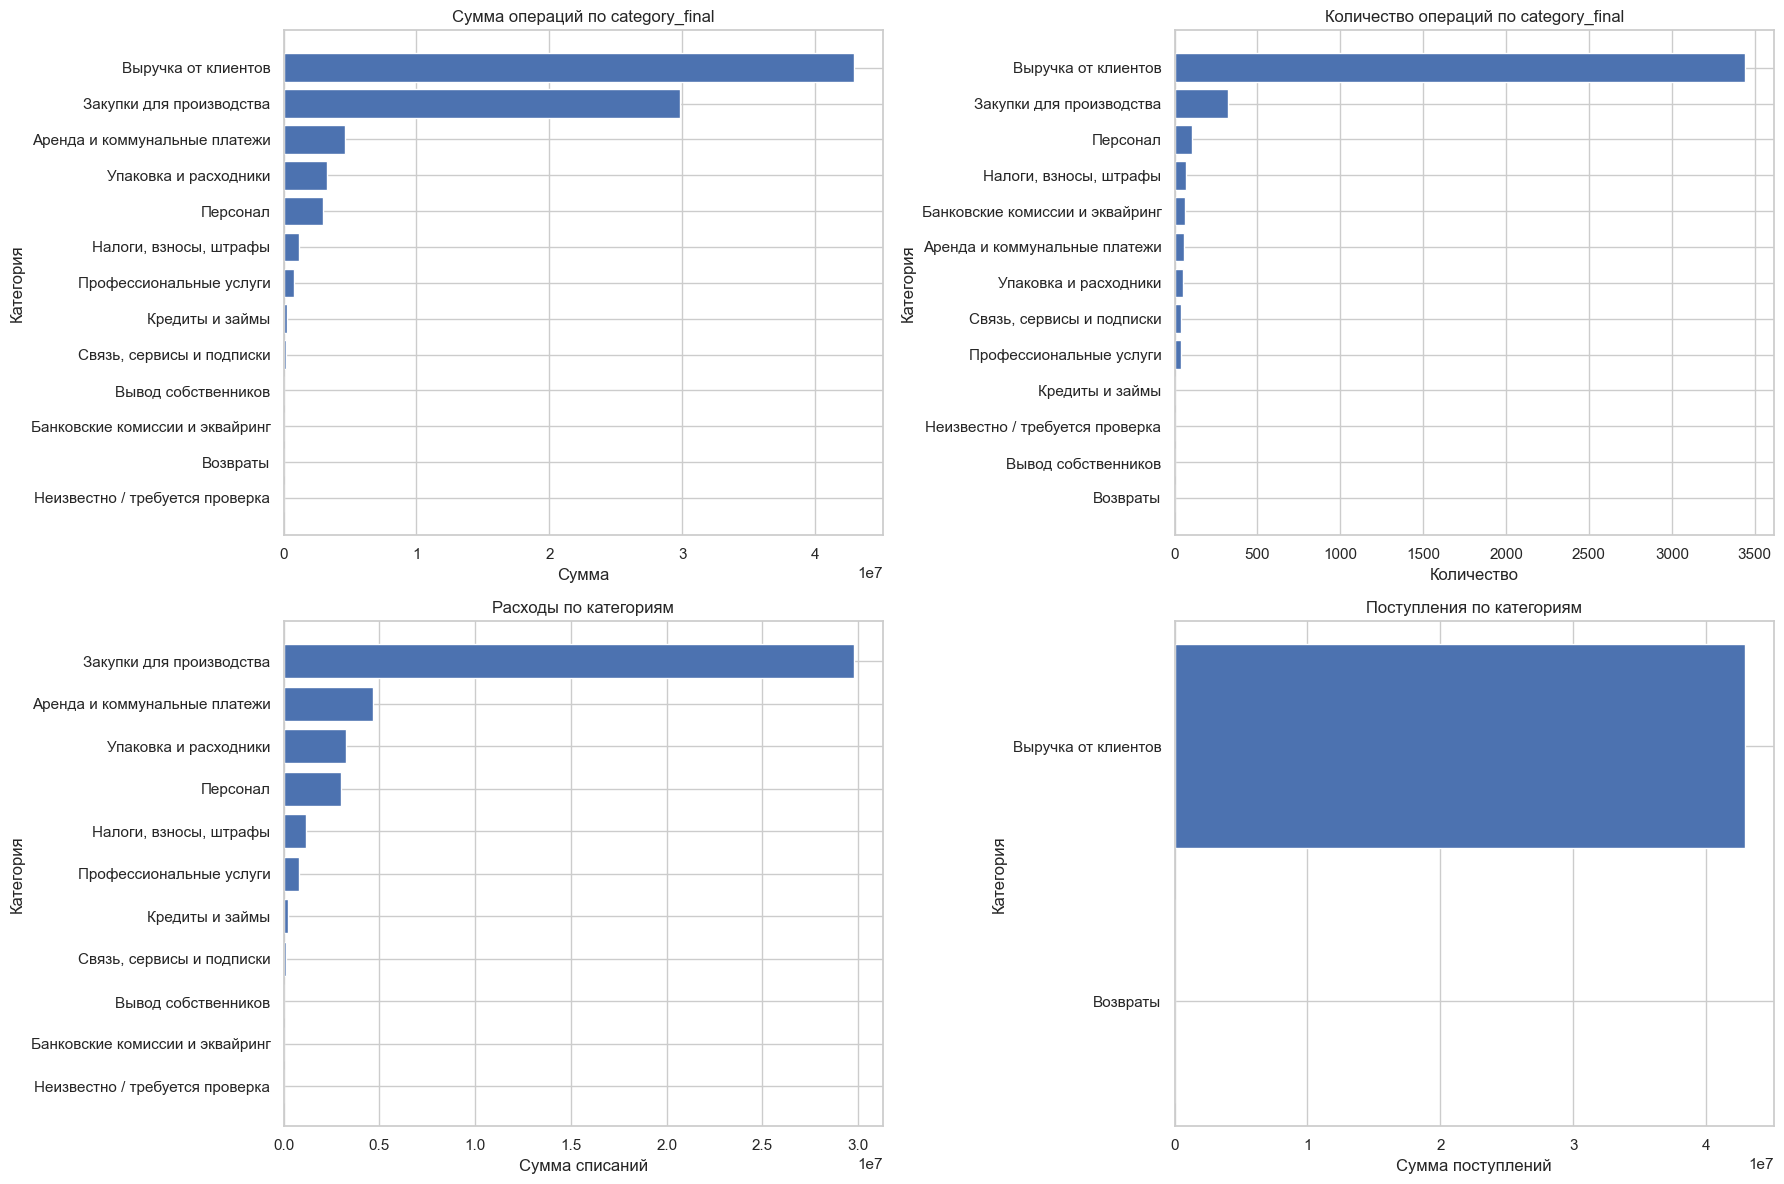

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

category_amount = category_summary.sort_values('amount', ascending=True)
axes[0, 0].barh(category_amount['category_final'], category_amount['amount'])
axes[0, 0].set_title('Сумма операций по category_final')
axes[0, 0].set_xlabel('Сумма')
axes[0, 0].set_ylabel('Категория')

category_count = bank['category_final'].value_counts().sort_values(ascending=True)
axes[0, 1].barh(category_count.index, category_count.values)
axes[0, 1].set_title('Количество операций по category_final')
axes[0, 1].set_xlabel('Количество')
axes[0, 1].set_ylabel('Категория')

expense_by_category = bank.loc[bank['operation_type'].eq('debit')].groupby('category_final')['amount'].sum().sort_values(ascending=True)
axes[1, 0].barh(expense_by_category.index, expense_by_category.values)
axes[1, 0].set_title('Расходы по категориям')
axes[1, 0].set_xlabel('Сумма списаний')
axes[1, 0].set_ylabel('Категория')

inflow_by_category = bank.loc[bank['operation_type'].eq('credit')].groupby('category_final')['amount'].sum().sort_values(ascending=True)
axes[1, 1].barh(inflow_by_category.index, inflow_by_category.values)
axes[1, 1].set_title('Поступления по категориям')
axes[1, 1].set_xlabel('Сумма поступлений')
axes[1, 1].set_ylabel('Категория')

plt.tight_layout()


## Ручная валидационная выборка 500 операций

In [ ]:
def take_unique(source: pd.DataFrame, limit: int, already_selected: set[int]) -> pd.DataFrame:
    if source.empty or limit <= 0:
        return source.head(0)
    candidates = source.loc[~source['operation_id'].isin(already_selected)].copy()
    result = candidates.head(limit)
    already_selected.update(result['operation_id'].tolist())
    return result

selected_ids: set[int] = set()
validation_parts = []

validation_parts.append(take_unique(bank.loc[bank['category_final'].eq(UNKNOWN_CATEGORY)].sort_values('amount', ascending=False), 120, selected_ids))
validation_parts.append(take_unique(classification_disagreements.sort_values('amount', ascending=False), 150, selected_ids))
validation_parts.append(take_unique(bank.loc[bank['amount'].ge(bank['amount'].quantile(0.90))].sort_values('amount', ascending=False), 100, selected_ids))
validation_parts.append(take_unique(bank.loc[bank['date'].isna()].sort_values('amount', ascending=False), 50, selected_ids))
validation_parts.append(take_unique(bank.loc[bank['text_clean'].str.contains(complex_terms, regex=True, na=False)].sort_values('amount', ascending=False), 120, selected_ids))

remaining_limit = VALIDATION_SAMPLE_SIZE - sum(len(part) for part in validation_parts)
if remaining_limit > 0:
    random_parts = []
    per_category = max(1, int(np.ceil(remaining_limit / max(bank['category_final'].nunique(), 1))))
    for _, group in bank.loc[~bank['operation_id'].isin(selected_ids)].groupby('category_final'):
        random_parts.append(group.sample(min(per_category, len(group)), random_state=RANDOM_STATE))
    random_stratified = pd.concat(random_parts, ignore_index=True) if random_parts else bank.head(0)
    validation_parts.append(take_unique(random_stratified.sample(frac=1, random_state=RANDOM_STATE), remaining_limit, selected_ids))

remaining_limit = VALIDATION_SAMPLE_SIZE - sum(len(part) for part in validation_parts)
if remaining_limit > 0:
    validation_parts.append(take_unique(bank.sample(frac=1, random_state=RANDOM_STATE), remaining_limit, selected_ids))

manual_validation = pd.concat(validation_parts, ignore_index=True).drop_duplicates('operation_id').head(VALIDATION_SAMPLE_SIZE)
manual_validation = manual_validation[[
    'operation_id', 'date', 'operation_type', 'amount', 'counterparty', 'description',
    'category_rule', 'subcategory_rule', 'rule_confidence',
    'category_llm', 'subcategory_llm', 'llm_confidence',
    'category_final', 'subcategory_final', 'category_source', 'category_confidence',
    'needs_review', 'review_reason'
]].copy()
manual_validation['category_manual'] = ''
manual_validation['subcategory_manual'] = ''
manual_validation['comment_manual'] = ''

print('Размер validation sample:', manual_validation.shape)
display(manual_validation.head(20))


Размер validation sample: (500, 21)
CSV: /Users/pavelesipenok/Documents/New project/Исследование разметки транзакций/outputs/manual_validation_500.csv
XLSX: /Users/pavelesipenok/Documents/New project/Исследование разметки транзакций/outputs/manual_validation_500.xlsx


,operation_id,date,operation_type,amount,counterparty,description,category_rule,subcategory_rule,rule_confidence,category_llm,subcategory_llm,llm_confidence,category_final,subcategory_final,category_source,category_confidence,needs_review,review_reason,category_manual,subcategory_manual,comment_manual
0,3512,2026-03-24,debit,"5,793.30",Семейкин Лев Петрович,Оплата по претензии от 08.02.2026. получено 13.03.2026г. НДС не облагается,Неизвестно / требуется проверка,неизвестно,0.00,Неизвестно / требуется проверка,неизвестно,0.00,Неизвестно / требуется проверка,неизвестно,rule_low_confidence,0.00,True,неизвестная категория; низкая уверенность,,,
1,1528,2025-10-21,debit,"672,980.00","ООО ""РАДУГА Н""","Оплата по счету № 475 от 21.10.2025. за крем на растит маслах д/ взбивания, сумма 34980,00 в т. ч. ндс 20% 5830,00; молокосодержащий продукт с заменит. мол. жира сумма 638000,00руб в тч ндс 10% 58000,00руб .",Закупки для производства,молочная продукция / сгущёнка,0.94,Неизвестно / требуется проверка,неизвестно,0.00,Закупки для производства,молочная продукция / сгущёнка,rule,0.94,True,крупная сумма,,,
2,1991,2025-11-24,debit,"455,200.00","ООО ""РАДУГА Н""","Оплата по счету № 518 от 24.11.2025. за маргарин столовый, молокосодержащий продукт, сумма 275200-00. В том числе НДС 10%, 25018-18 руб. какао-порошок алкализированный, сумма 180000-00, в т. ч ндс 20% 30000-00.",Закупки для производства,молочная продукция / сгущёнка,0.94,Неизвестно / требуется проверка,неизвестно,0.00,Закупки для производства,молочная продукция / сгущёнка,rule,0.94,True,крупная сумма,,,
3,1995,2025-11-24,debit,"450,000.00","ООО ""РАДУГА Н""","Оплата по счету № 518 от 24.11.2025. за маргарин столовый, молокосодержащий продукт с сахаром со вкусом ""вареная сгущенка"". В том числе НДС 10%, 40909.09 руб.Частично",Закупки для производства,сахар,0.94,Неизвестно / требуется проверка,неизвестно,0.00,Закупки для производства,сахар,rule,0.94,True,крупная сумма,,,
4,1234,2025-09-30,debit,"450,000.00","ООО ""РАДУГА Н""","Оплата по счету № 445 от 30.09.2025. за заменитель молочного жира, сумма 213 000,00 в т. ч ндс 10% 19393,64 , начинку кондитерскую пастеризованную термостабильную. сумма 237000,00. НДС 20% 39500,00 Частично",Закупки для производства,масло / жиры,0.94,Неизвестно / требуется проверка,неизвестно,0.00,Закупки для производства,масло / жиры,rule,0.94,True,крупная сумма,,,
5,2378,2025-12-18,debit,"411,200.00","ООО ""РАДУГА Н""","Оплата по счету № 546 от 18.12.2025. за начинку кондит, ванилин, кокосовую стружку сумма 315200-00. В том числе НДС 20%, 52533-33 руб. , маргарин, сумма 96000-00, в т. ч ндс 10% 8727-27руб.",Закупки для производства,масло / жиры,0.94,Неизвестно / требуется проверка,неизвестно,0.00,Закупки для производства,масло / жиры,rule,0.94,True,крупная сумма,,,
6,1820,2025-11-10,debit,"383,250.00","ООО ""РАДУГА Н""","Оплата по счету № 499 от 10.11.2025. за сахар-песок. В том числе НДС 10%, 34840.91 руб.",Закупки для производства,сахар,0.94,Неизвестно / требуется проверка,неизвестно,0.00,Закупки для производства,сахар,rule,0.94,True,крупная сумма,,,
7,2068,2025-11-27,debit,"371,700.00","ООО ""РАДУГА Н""","Оплата по счету № 525 от 27.11.2025. сахар-песок, сумма 137400-00. В том числе НДС 10%, 12518-18 руб. полуфабрикат кондитерский, сумма 234000-00, в т. ч ндс 20% 39000-00 руб",Закупки для производства,сахар,0.94,Неизвестно / требуется проверка,неизвестно,0.00,Закупки для производства,сахар,rule,0.94,True,крупная сумма,,,
8,1932,2025-11-18,debit,"369,950.00","ООО ""РАДУГА Н""","Оплата по счету № 508 от 18.11.2025. за маргарин столовый, маргарин для слоенного теста. В том числе НДС 10%, 33631.82 руб.",Закупки для производства,масло / жиры,0.94,Неизвестно / требуется проверка,неизвестно,0.00,Закупки для производства,масло / жиры,rule,0.94,True,крупная сумма,,,
9,2861,2026-02-03,debit,"353,750.00","ООО ""РАДУГА Н""","Оплата по счету № 31 от 03.02.2026. за ванилин сумма 123750-00. В том числе НДС 22%, 22315-57 руб. ; маргарин столовый 230000-00 в т. ч. ндс 10% 

## Оценка качества после ручной разметки

In [ ]:
def load_labeled_validation() -> pd.DataFrame | None:
    xlsx_path = OUTPUTS_DIR / 'manual_validation_500_labeled.xlsx'
    csv_path = OUTPUTS_DIR / 'manual_validation_500_labeled.csv'
    if xlsx_path.exists():
        return pd.read_excel(xlsx_path)
    if csv_path.exists():
        return pd.read_csv(csv_path)
    return None


def evaluate_predictions(labeled: pd.DataFrame, prediction_column: str, target_column: str = 'category_manual') -> dict:
    valid = labeled[target_column].notna() & labeled[target_column].astype(str).str.strip().ne('')
    data = labeled.loc[valid].copy()
    if data.empty or prediction_column not in data.columns:
        return {'variant': prediction_column, 'accuracy': np.nan, 'macro_f1': np.nan, 'weighted_f1': np.nan, 'rows': len(data)}
    return {
        'variant': prediction_column,
        'accuracy': accuracy_score(data[target_column], data[prediction_column]),
        'macro_f1': f1_score(data[target_column], data[prediction_column], average='macro', zero_division=0),
        'weighted_f1': f1_score(data[target_column], data[prediction_column], average='weighted', zero_division=0),
        'rows': len(data),
    }

labeled_validation = load_labeled_validation()
if labeled_validation is None:
    print('Заполните category_manual в outputs/manual_validation_500.xlsx и сохраните файл как outputs/manual_validation_500_labeled.xlsx для оценки качества классификации.')
else:
    labeled_validation['category_manual'] = labeled_validation['category_manual'].astype(str).str.strip()
    metrics = pd.DataFrame([
        evaluate_predictions(labeled_validation, 'category_rule'),
        evaluate_predictions(labeled_validation, 'category_llm'),
        evaluate_predictions(labeled_validation, 'category_final'),
    ])
    display(metrics)

    valid = labeled_validation['category_manual'].notna() & labeled_validation['category_manual'].astype(str).str.strip().ne('')
    eval_labeled = labeled_validation.loc[valid].copy()
    for column in ['category_rule', 'category_llm', 'category_final']:
        if column in eval_labeled.columns:
            print('\n', column)
            print(classification_report(eval_labeled['category_manual'], eval_labeled[column], zero_division=0))

    if not eval_labeled.empty:
        labels = sorted(set(eval_labeled['category_manual']).union(set(eval_labeled['category_final'])))
        cm = confusion_matrix(eval_labeled['category_manual'], eval_labeled['category_final'], labels=labels)
        fig, ax = plt.subplots(figsize=(12, 10))
        if sns:
            sns.heatmap(cm, xticklabels=labels, yticklabels=labels, cmap='Blues', ax=ax)
        else:
            ax.imshow(cm, cmap='Blues')
            ax.set_xticks(range(len(labels)), labels, rotation=90)
            ax.set_yticks(range(len(labels)), labels)
        ax.set_title('Confusion matrix: category_final vs category_manual')
        ax.set_xlabel('Предсказание')
        ax.set_ylabel('Ручная разметка')
        plt.tight_layout()

        errors = eval_labeled.loc[eval_labeled['category_final'].ne(eval_labeled['category_manual'])].copy()
        error_summary = errors.groupby(['category_manual', 'category_final']).size().reset_index(name='errors').sort_values('errors', ascending=False)
        display(error_summary.head(30))
        display(errors.head(30))


Заполните category_manual в outputs/manual_validation_500.xlsx и сохраните файл как outputs/manual_validation_500_labeled.xlsx для оценки качества классификации.


## Корректный Cash Flow

In [ ]:
CASH_FLOW_SECTION = {
    'Выручка от клиентов': 'operating_inflow',
    'Прочие поступления': 'operating_inflow',
    'Закупки для производства': 'operating_outflow',
    'Упаковка и расходники': 'operating_outflow',
    'Персонал': 'operating_outflow',
    'Аренда и коммунальные платежи': 'operating_outflow',
    'Связь, сервисы и подписки': 'operating_outflow',
    'Логистика и доставка': 'operating_outflow',
    'Маркетинг и реклама': 'operating_outflow',
    'Банковские комиссии и эквайринг': 'operating_outflow',
    'Профессиональные услуги': 'operating_outflow',
    'Налоги, взносы, штрафы': 'operating_outflow',
    'Возвраты': 'operating_adjustment',
    'Кредиты и займы': 'financing',
    'Внутренние переводы': 'internal_transfer',
    'Вывод собственников': 'owner_withdrawal',
    'Неизвестно / требуется проверка': 'unknown',
}

bank['cash_flow_section'] = bank['category_final'].map(CASH_FLOW_SECTION).fillna('unknown')
bank['month'] = bank['date'].dt.to_period('M').astype(str).replace('NaT', np.nan)
missing_date_operations = bank.loc[bank['date'].isna()].copy()

cf_source = bank.loc[bank['date'].notna()].copy()
months = sorted(cf_source['month'].dropna().unique())
rows = []
for month, group in cf_source.groupby('month'):
    row = {'month': month}
    row['operating_inflows'] = group.loc[group['cash_flow_section'].eq('operating_inflow') & group['operation_type'].eq('credit'), 'amount'].sum()
    row['operating_outflows'] = group.loc[group['cash_flow_section'].eq('operating_outflow') & group['operation_type'].eq('debit'), 'amount'].sum()
    row['operating_cash_flow'] = row['operating_inflows'] - row['operating_outflows']
    row['financing_inflows'] = group.loc[group['cash_flow_section'].eq('financing') & group['operation_type'].eq('credit'), 'amount'].sum()
    row['financing_outflows'] = group.loc[group['cash_flow_section'].eq('financing') & group['operation_type'].eq('debit'), 'amount'].sum()
    row['owner_withdrawals'] = group.loc[group['cash_flow_section'].eq('owner_withdrawal') & group['operation_type'].eq('debit'), 'amount'].sum()
    row['internal_transfers_in'] = group.loc[group['cash_flow_section'].eq('internal_transfer') & group['operation_type'].eq('credit'), 'amount'].sum()
    row['internal_transfers_out'] = group.loc[group['cash_flow_section'].eq('internal_transfer') & group['operation_type'].eq('debit'), 'amount'].sum()
    row['returns_in'] = group.loc[group['cash_flow_section'].eq('operating_adjustment') & group['operation_type'].eq('credit'), 'amount'].sum()
    row['returns_out'] = group.loc[group['cash_flow_section'].eq('operating_adjustment') & group['operation_type'].eq('debit'), 'amount'].sum()
    row['unknown_inflows'] = group.loc[group['cash_flow_section'].eq('unknown') & group['operation_type'].eq('credit'), 'amount'].sum()
    row['unknown_outflows'] = group.loc[group['cash_flow_section'].eq('unknown') & group['operation_type'].eq('debit'), 'amount'].sum()
    non_internal = group.loc[~group['cash_flow_section'].eq('internal_transfer'), 'signed_amount'].sum()
    row['net_cash_flow_before_internal'] = non_internal
    row['net_cash_flow_after_internal'] = group['signed_amount'].sum()
    row['operations_count'] = len(group)
    row['needs_review_count'] = int(group['needs_review'].sum())
    row['needs_review_amount'] = group.loc[group['needs_review'], 'amount'].sum()
    rows.append(row)

cash_flow_by_month = pd.DataFrame(rows).sort_values('month')
display(cash_flow_by_month)
print('Операций без даты не включено в помесячный cash flow:', len(missing_date_operations))
print('Сумма операций без даты:', missing_date_operations['amount'].sum())


,month,operating_inflows,operating_outflows,operating_cash_flow,financing_inflows,financing_outflows,owner_withdrawals,internal_transfers_in,internal_transfers_out,returns_in,returns_out,unknown_inflows,unknown_outflows,net_cash_flow_before_internal,net_cash_flow_after_internal,operations_count,needs_review_count,needs_review_amount
0,2025-05,"971,329.80","1,035,650.02","-64,320.22",0.00,0.00,"35,000.00",0.00,0.00,"7,619.00",0.00,0.00,0.00,"-91,701.22","-91,701.22",220,0,0.00
1,2025-06,"1,145,115.02","998,547.04","146,567.98",0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,"146,567.98","146,567.98",195,7,"735,450.00"
2,2025-07,"1,874,679.72","1,962,956.59","-88,276.87",0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,"-88,276.87","-88,276.87",235,9,"1,112,924.59"
3,2025-08,"3,891,754.41","3,744,325.61","147,428.80",0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,"147,428.80","147,428.80",300,22,"2,953,685.50"
4,2025-09,"3,602,062.26","3,863,052.42","-260,990.16",0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,"-260,990.16","-260,990.16",284,23,"3,421,111.00"
5,2025-10,"5,768,109.82","5,615,202.61","152,907.21",0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,"152,907.21","152,907.21",460,29,"4,744,680.80"
6,2025-11,"5,661,947.73","5,383,176.61","278,771.12",0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,"278,771.12","278,771.12",398,29,"4,582,873.30"
7,2025-12,"5,146,962.60","5,322,154.48","-175,191.88",0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,"-175,191.88","-175,191.88",493,33,"4,508,759.80"
8,2026-01,"2,659,441.20","2,514,183.15","145,258.05",0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,"145,258.05","145,258.05",253,14,"2,095,402.50"
9,2026-02,"3,147,109.31","3,497,309.72","-350,200.41",0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,"-350,200.41","-350,200.41",355,19,"2,428,530.00"


Операций без даты не включено в помесячный cash flow: 0
Сумма операций без даты: 0.0


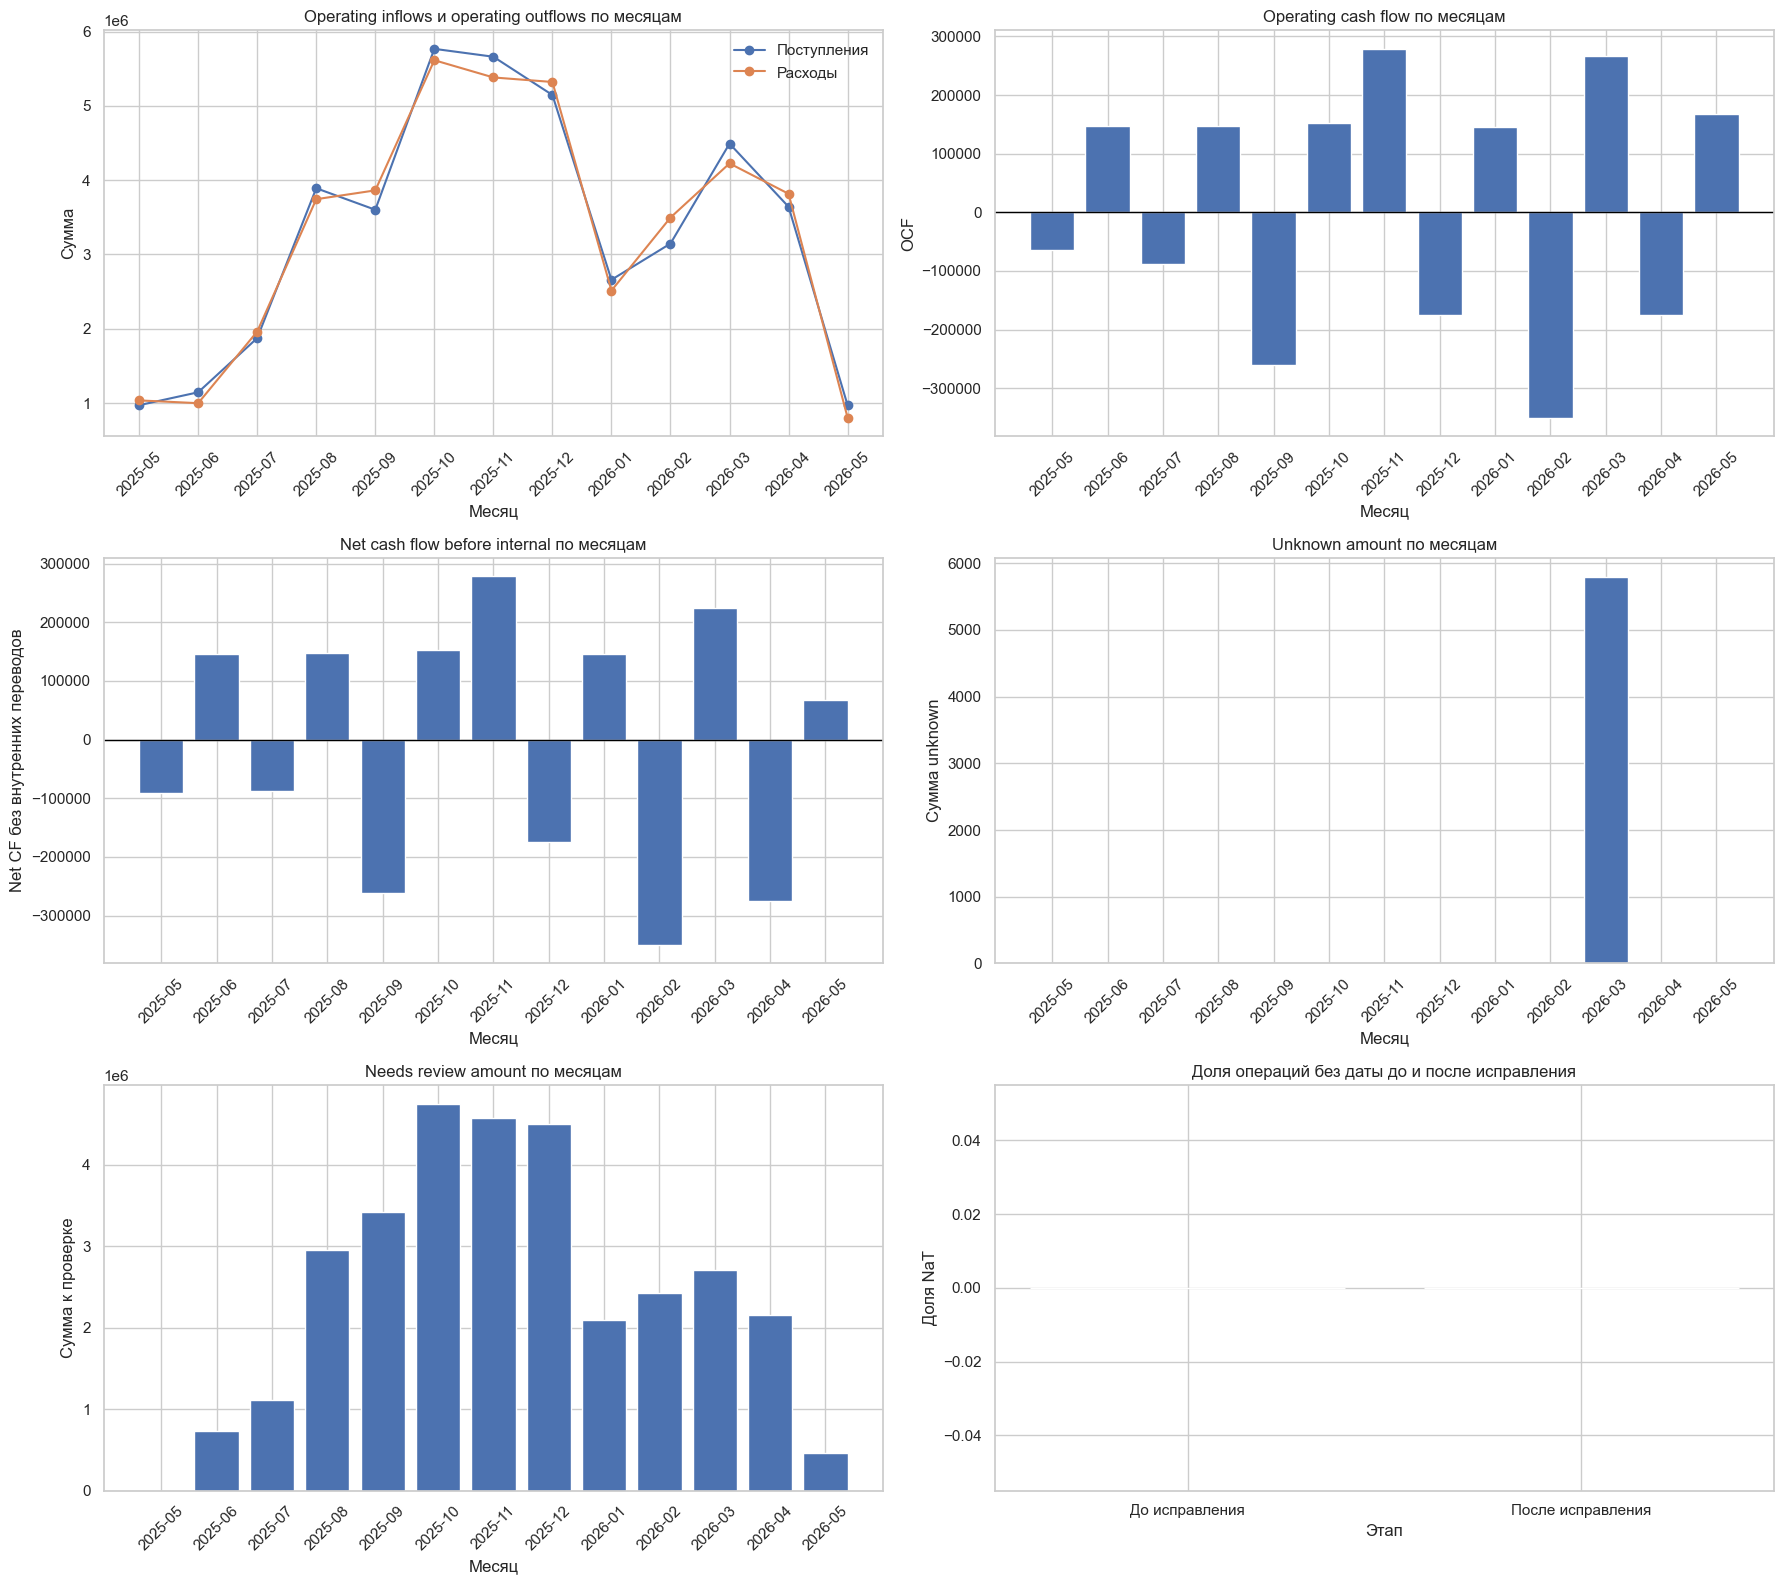

In [ ]:
fig, axes = plt.subplots(3, 2, figsize=(18, 16))
cf = cash_flow_by_month.copy()

axes[0, 0].plot(cf['month'], cf['operating_inflows'], marker='o', label='Поступления')
axes[0, 0].plot(cf['month'], cf['operating_outflows'], marker='o', label='Расходы')
axes[0, 0].set_title('Operating inflows и operating outflows по месяцам')
axes[0, 0].set_xlabel('Месяц')
axes[0, 0].set_ylabel('Сумма')
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].legend()

axes[0, 1].bar(cf['month'], cf['operating_cash_flow'])
axes[0, 1].axhline(0, color='black', linewidth=1)
axes[0, 1].set_title('Operating cash flow по месяцам')
axes[0, 1].set_xlabel('Месяц')
axes[0, 1].set_ylabel('OCF')
axes[0, 1].tick_params(axis='x', rotation=45)

axes[1, 0].bar(cf['month'], cf['net_cash_flow_before_internal'])
axes[1, 0].axhline(0, color='black', linewidth=1)
axes[1, 0].set_title('Net cash flow before internal по месяцам')
axes[1, 0].set_xlabel('Месяц')
axes[1, 0].set_ylabel('Net CF без внутренних переводов')
axes[1, 0].tick_params(axis='x', rotation=45)

unknown_amount = cf['unknown_inflows'] + cf['unknown_outflows']
axes[1, 1].bar(cf['month'], unknown_amount)
axes[1, 1].set_title('Unknown amount по месяцам')
axes[1, 1].set_xlabel('Месяц')
axes[1, 1].set_ylabel('Сумма unknown')
axes[1, 1].tick_params(axis='x', rotation=45)

axes[2, 0].bar(cf['month'], cf['needs_review_amount'])
axes[2, 0].set_title('Needs review amount по месяцам')
axes[2, 0].set_xlabel('Месяц')
axes[2, 0].set_ylabel('Сумма к проверке')
axes[2, 0].tick_params(axis='x', rotation=45)

date_loss = pd.Series({'До исправления': bank_raw.get('operation_date', pd.Series(dtype=object)).isna().mean(), 'После исправления': bank['date'].isna().mean()})
axes[2, 1].bar(date_loss.index, date_loss.values)
axes[2, 1].set_title('Доля операций без даты до и после исправления')
axes[2, 1].set_xlabel('Этап')
axes[2, 1].set_ylabel('Доля NaT')

plt.tight_layout()


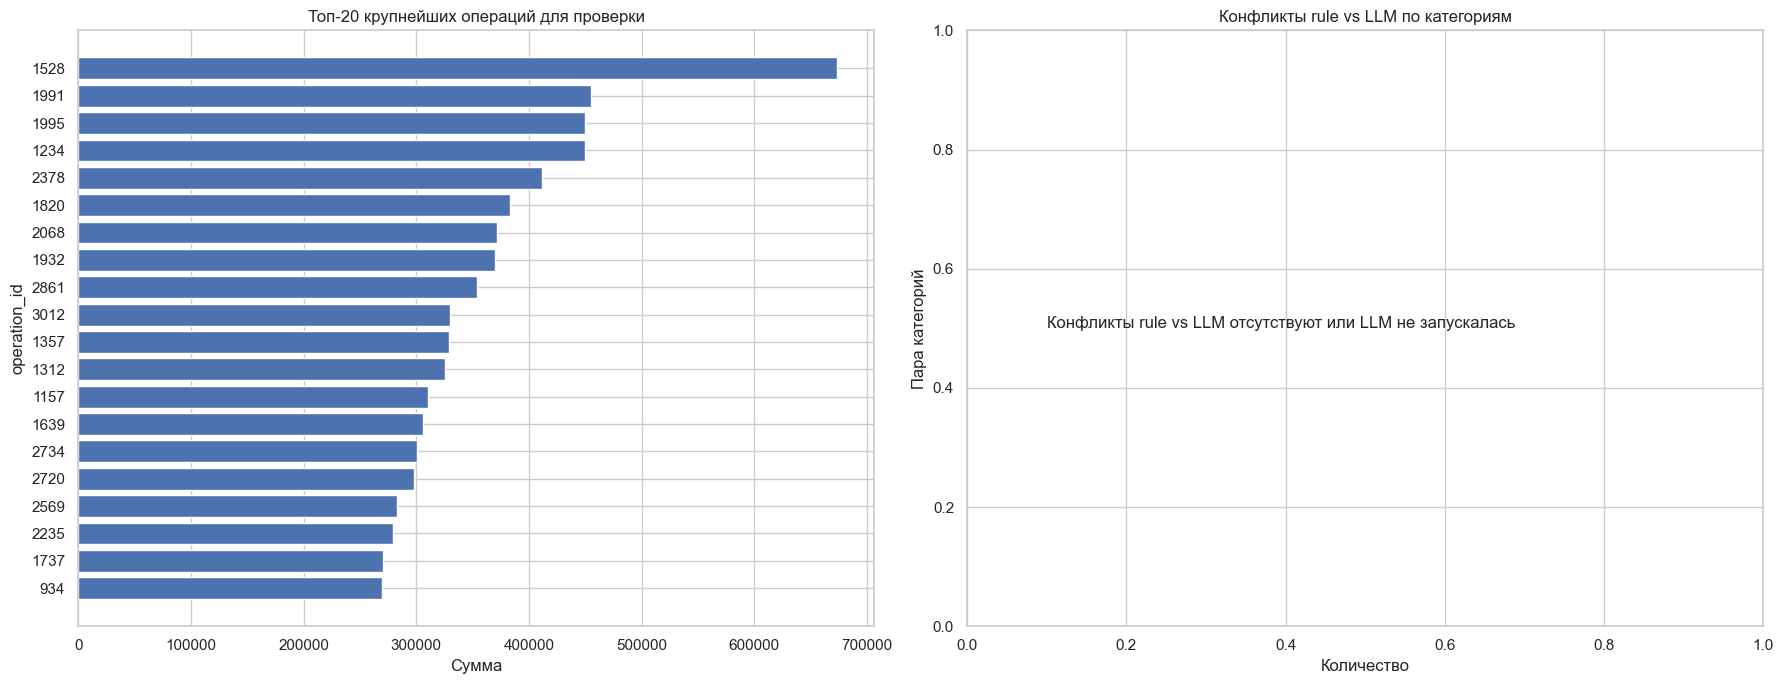

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

top_review = bank.sort_values('amount', ascending=False).head(20)
axes[0].barh(top_review['operation_id'].astype(str), top_review['amount'])
axes[0].invert_yaxis()
axes[0].set_title('Топ-20 крупнейших операций для проверки')
axes[0].set_xlabel('Сумма')
axes[0].set_ylabel('operation_id')

if not classification_disagreements.empty:
    conflict_counts = classification_disagreements.groupby(['category_rule', 'category_llm']).size().reset_index(name='count').sort_values('count', ascending=True).tail(20)
    labels = conflict_counts['category_rule'] + ' → ' + conflict_counts['category_llm']
    axes[1].barh(labels, conflict_counts['count'])
else:
    axes[1].text(0.1, 0.5, 'Конфликты rule vs LLM отсутствуют или LLM не запускалась')
axes[1].set_title('Конфликты rule vs LLM по категориям')
axes[1].set_xlabel('Количество')
axes[1].set_ylabel('Пара категорий')

plt.tight_layout()



## Углублённая аналитика: где реально застревают деньги

Этот блок не просто показывает распределения. Он отвечает на управленческие вопросы:

- какие категории и контрагенты создают основную нагрузку на деньги;
- в какие месяцы операционный поток выглядит слабым;
- какие платежи повторяются и похожи на постоянную базу расходов;
- насколько бизнес зависит от топ-клиентов и топ-поставщиков;
- какие операции надо открыть глазами, потому что назначение платежа важнее категории.


In [183]:

# --- Управленческие срезы по денежному потоку ---
analysis_bank = bank.copy()
analysis_bank['is_inflow'] = analysis_bank['operation_type'].eq('credit')
analysis_bank['is_outflow'] = analysis_bank['operation_type'].eq('debit')
analysis_bank['amount_signed_for_plot'] = np.where(analysis_bank['is_inflow'], analysis_bank['amount'], -analysis_bank['amount'])

# 1. Расходы по категориям и их доля в операционных поступлениях.
operating_inflow_total = analysis_bank.loc[analysis_bank['category_final'].isin(CATEGORY_GROUPS['Операционные поступления']) & analysis_bank['is_inflow'], 'amount'].sum()
expense_concentration = (
    analysis_bank.loc[analysis_bank['is_outflow']]
    .groupby('category_final')
    .agg(
        operations=('operation_id', 'size'),
        amount=('amount', 'sum'),
        counterparties=('counterparty', 'nunique'),
        needs_review_amount=('amount', lambda values: values[analysis_bank.loc[values.index, 'needs_review']].sum()),
    )
    .reset_index()
    .sort_values('amount', ascending=False)
)
expense_concentration['share_of_debit'] = expense_concentration['amount'] / max(analysis_bank.loc[analysis_bank['is_outflow'], 'amount'].sum(), 1)
expense_concentration['share_of_operating_inflow'] = expense_concentration['amount'] / max(operating_inflow_total, 1)
display(expense_concentration)

# 2. Топ контрагентов по оттоку/притоку.
counterparty_cash_impact = (
    analysis_bank.groupby(['counterparty', 'operation_type'], dropna=False)
    .agg(
        operations=('operation_id', 'size'),
        amount=('amount', 'sum'),
        categories=('category_final', lambda values: ' | '.join(sorted(set(map(str, values))))),
    )
    .reset_index()
    .sort_values('amount', ascending=False)
)

top_debit_counterparties = counterparty_cash_impact.loc[counterparty_cash_impact['operation_type'].eq('debit')].head(25)
top_credit_counterparties = counterparty_cash_impact.loc[counterparty_cash_impact['operation_type'].eq('credit')].head(25)
display(top_debit_counterparties)
display(top_credit_counterparties)

# 3. Концентрация клиентов и поставщиков: если немного контрагентов дают/забирают большую долю денег, это риск.
client_concentration = top_credit_counterparties.copy()
client_concentration['share_of_credit'] = client_concentration['amount'] / max(analysis_bank.loc[analysis_bank['is_inflow'], 'amount'].sum(), 1)
client_concentration['cumulative_share'] = client_concentration['share_of_credit'].cumsum()

supplier_concentration = top_debit_counterparties.copy()
supplier_concentration['share_of_debit'] = supplier_concentration['amount'] / max(analysis_bank.loc[analysis_bank['is_outflow'], 'amount'].sum(), 1)
supplier_concentration['cumulative_share'] = supplier_concentration['share_of_debit'].cumsum()

# 4. Повторяющиеся платежи: регулярная база расходов, которая давит на cash flow каждый месяц.
recurring_candidates = analysis_bank.loc[analysis_bank['is_outflow']].copy()
recurring_candidates['amount_bucket_1000'] = (recurring_candidates['amount'] / 1000).round() * 1000
recurring_payments = (
    recurring_candidates.groupby(['counterparty', 'category_final', 'subcategory_final', 'amount_bucket_1000'], dropna=False)
    .agg(
        operations=('operation_id', 'size'),
        months=('month', 'nunique'),
        total_amount=('amount', 'sum'),
        min_amount=('amount', 'min'),
        max_amount=('amount', 'max'),
        example_description=('description', 'first'),
    )
    .reset_index()
)
recurring_payments = recurring_payments.loc[(recurring_payments['operations'] >= 3) | (recurring_payments['months'] >= 3)]
recurring_payments = recurring_payments.sort_values('total_amount', ascending=False)
display(recurring_payments.head(40))

# 5. Месячная динамика категорий расходов: где был скачок.
monthly_category_outflows = (
    analysis_bank.loc[analysis_bank['is_outflow']]
    .pivot_table(index='month', columns='category_final', values='amount', aggfunc='sum', fill_value=0)
    .sort_index()
)
monthly_category_growth = monthly_category_outflows.pct_change().replace([np.inf, -np.inf], np.nan)
category_growth_long = (
    monthly_category_growth.stack(dropna=True)
    .reset_index(name='mom_growth')
    .merge(monthly_category_outflows.stack().reset_index(name='amount'), on=['month', 'category_final'], how='left')
    .sort_values(['mom_growth', 'amount'], ascending=[False, False])
)
display(category_growth_long.loc[category_growth_long['amount'].gt(50000)].head(30))

# 6. Cash pressure: месяцы, где операционный поток слабый или деньги съедаются неоперационными блоками.
cash_pressure = cash_flow_by_month.copy()
cash_pressure['outflow_to_inflow_ratio'] = cash_pressure['operating_outflows'] / cash_pressure['operating_inflows'].replace(0, np.nan)
cash_pressure['ocf_margin'] = cash_pressure['operating_cash_flow'] / cash_pressure['operating_inflows'].replace(0, np.nan)
cash_pressure['non_operating_drag'] = cash_pressure['operating_cash_flow'] - cash_pressure['net_cash_flow_before_internal']
cash_pressure['unknown_total'] = cash_pressure['unknown_inflows'] + cash_pressure['unknown_outflows']
cash_pressure['risk_flags'] = ''
cash_pressure.loc[cash_pressure['operating_cash_flow'].lt(0), 'risk_flags'] += 'отрицательный OCF; '
cash_pressure.loc[cash_pressure['net_cash_flow_before_internal'].lt(0), 'risk_flags'] += 'отрицательный net CF; '
cash_pressure.loc[cash_pressure['outflow_to_inflow_ratio'].gt(0.9), 'risk_flags'] += 'расходы >90% поступлений; '
cash_pressure.loc[cash_pressure['needs_review_amount'].gt(cash_pressure['operating_inflows'] * 0.2), 'risk_flags'] += 'много операций к проверке; '
display(cash_pressure.sort_values(['risk_flags', 'net_cash_flow_before_internal'], ascending=[False, True]))

# 7. Подсветка назначений платежа для ручного просмотра.
KEY_TERMS_FOR_HIGHLIGHT = [
    'меланж', 'белок', 'мук', 'сахар', 'сгущ', 'маргарин', 'масло', 'начинк', 'упаков', 'короб',
    'аренд', 'депозит', 'комис', 'ком-я', 'под отчет', 'услуги', 'договор', 'кредит', 'лизинг',
    'вывоз', 'тензор', '1с', 'saby', 'возврат', 'претенз'
]

def highlight_description(text: str) -> str:
    highlighted = str(text)
    for term in sorted(KEY_TERMS_FOR_HIGHLIGHT, key=len, reverse=True):
        highlighted = re.sub(f'({re.escape(term)})', r'**\1**', highlighted, flags=re.IGNORECASE)
    return highlighted

highlighted_review = analysis_bank.loc[
    analysis_bank['needs_review'] | analysis_bank['amount'].ge(analysis_bank['amount'].quantile(0.95))
].copy()
highlighted_review['highlighted_description'] = highlighted_review['description'].map(highlight_description)
highlighted_review = highlighted_review[[
    'operation_id', 'date', 'operation_type', 'amount', 'counterparty', 'category_final', 'subcategory_final',
    'category_confidence', 'review_reason', 'highlighted_description'
]].sort_values('amount', ascending=False)
display(highlighted_review.head(50))


,category_final,operations,amount,counterparties,needs_review_amount,share_of_debit,share_of_operating_inflow
3,Закупки для производства,321,"29,804,202.60",14,"22,213,520.40",0.69,0.69
0,Аренда и коммунальные платежи,56,"4,642,628.93",6,"4,130,926.50",0.11,0.11
10,Упаковка и расходники,50,"3,252,205.74",5,"2,306,124.59",0.08,0.08
7,Персонал,106,"2,971,955.00",6,"1,683,827.00",0.07,0.07
5,"Налоги, взносы, штрафы",66,"1,156,005.00",2,"170,000.00",0.03,0.03
8,Профессиональные услуги,36,"783,500.60",3,"734,000.00",0.02,0.02
4,Кредиты и займы,3,"234,479.94",1,"198,479.94",0.01,0.01
9,"Связь, сервисы и подписки",41,"144,464.48",4,0.00,0.00,0.00
2,Вывод собственников,1,"35,000.00",1,0.00,0.00,0.00
1,Банковские комиссии и эквайринг,64,"28,108.26",2,0.00,0.00,0.00


,counterparty,operation_type,operations,amount,categories
64,"ООО ""РАДУГА Н""",debit,67,"14,700,980.00",Закупки для производства
251,"ООО ""ФРУТКРЕМ БЕЛОВА""",debit,89,"4,839,400.00",Закупки для производства
5,ИП Баскаков С. А.,debit,21,"3,802,539.70",Аренда и коммунальные платежи
61,"ООО ""МЕЛАНЖ""",debit,60,"3,462,672.00",Закупки для производства
3,"АО ""ТУЛАХЛЕБОПРОДУКТ""",debit,42,"2,488,500.00",Закупки для производства
68,"ООО ""ТК ""ШЕБЕКИНСКИЙ КАРТОН""",debit,33,"1,938,727.74",Упаковка и расходники
11,Мишаткина Марина Викторовна,debit,23,"1,529,727.00",Персонал
12,"ООО ""АРТКОНДИ""",debit,21,"1,330,306.00",Закупки для производства
48,"ООО ""ГИЛЬДИЯ ""РОМБ""",debit,16,"1,198,785.00",Закупки для производства
9,Казначейство России ( ФНС России),debit,64,"1,155,970.00","Налоги, взносы, штрафы"


,counterparty,operation_type,operations,amount,categories
69,"ООО ""ТОРГСЕРВИС 150""",credit,88,"1,473,544.15",Выручка от клиентов
202,"ООО ""ТОРГСЕРВИС 71""",credit,138,"1,323,615.82",Выручка от клиентов
113,"ООО ""ТОРГСЕРВИС 150"" Р/С 40702810640000407989 в ПАО Сбербанк г Москва",credit,14,"610,257.50",Выручка от клиентов
199,"ООО ""ТОРГСЕРВИС 50"" Р/С 40702810940000064297 в ПАО Сбербанк г Москва",credit,19,"528,235.00",Выручка от клиентов
105,"ООО ""ТОРГСЕРВИС 150"" Р/С 40702810540000075440 в ПАО Сбербанк г Москва",credit,16,"511,935.00",Выручка от клиентов
108,"ООО ""ТОРГСЕРВИС 150"" Р/С 40702810540000092151 в ПАО Сбербанк г Москва",credit,15,"485,632.50",Выручка от клиентов
242,"ООО ""ТОРГСЕРВИС 71"" Р/С 40702810866000016175 в ПАО Сбербанк г Москва",credit,42,"478,868.90",Выручка от клиентов
18,"ООО ""ВОСТОРГ 76"" Р/С 40702810077030025663 в ПАО Сбербанк г Москва",credit,37,"476,420.13",Выручка от клиентов
125,"ООО ""ТОРГСЕРВИС 150"" Р/С 40702810840000080685 в ПАО Сбербанк г Москва",credit,17,"474,930.00",Выручка от клиентов
160,"ООО ""ТОРГСЕРВИС 50"" Р/С 40702810240000030772 в ПАО Сбербанк г Москва",credit,20,"455,676.70",Выручка от клиентов


,counterparty,category_final,subcategory_final,amount_bucket_1000,operations,months,total_amount,min_amount,max_amount,example_description
42,ИП Баскаков С. А.,Аренда и коммунальные платежи,аренда,"222,000.00",9,9,"1,999,620.00","222,180.00","222,180.00","Оплата по счету № 5683 от 01.08. 2025г. Постоянная часть арендной платы по договору Б/О-56/25 от 25.06.2025. за август 2025г. В том числе НДС 5%, 10580.00 руб."
312,"ООО ""ФРУТКРЕМ БЕЛОВА""",Закупки для производства,начинки / добавки,"95,000.00",21,7,"1,995,000.00","95,000.00","95,000.00","Оплата по счету № 133 от 21 июля 2025г за начинку кондитерскую со вкусом ванили. В том числе НДС 20%, 15833.33 руб."
26,"АО ""ТУЛАХЛЕБОПРОДУКТ""",Закупки для производства,мука,"65,000.00",23,7,"1,495,000.00","65,000.00","65,000.00","Оплата по упд № 1808-0000005 от 18.08. 2025. за муку в/с. В том числе НДС 10%, 5909.09 руб."
271,"ООО ""ТК ""ШЕБЕКИНСКИЙ КАРТОН""",Упаковка и расходники,коробки,"100,000.00",7,4,"700,000.00","100,000.00","100,000.00","Оплата по УПД № 1288 от 28.05.2025 за гофролоток. В том числе НДС 20%, 16666.67 руб. Частично."
219,"ООО ""РАДУГА Н""",Закупки для производства,молочная продукция / сгущёнка,"200,000.00",3,2,"600,200.00","199,980.00","200,220.00","оплата по счету № 411 от 09.09.2025. за молокосодержащий продукт с заменителем молочного жира "" вареная сгущенка"". В том числе НДС 10%, 18201.82 руб"
189,"ООО ""РАДУГА Н""",Закупки для производства,масло / жиры,"100,000.00",6,2,"600,000.00","100,000.00","100,000.00","Оплата по счету № 74 от 10.03.2026. . за маргарин. В том числе НДС 10%, 9090.91 руб. частично"
132,"ООО ""КЗГ""",Упаковка и расходники,печатные формы,"100,000.00",5,2,"500,000.00","100,000.00","100,000.00","Оплата по упд № 107 от 23.02.2026. за гофрокороб. В том числе НДС 22%, 18032.79 руб. частично"
188,"ООО ""ППР""",Профессиональные услуги,прочие услуги по договору,"30,000.00",15,4,"450,000.00","30,000.00","30,000.00","Оплата по договору № 77600100252491125 от 13.11.2025г. В том числе НДС 20%, 5000.00 руб."
157,"ООО ""МЕЛАНЖ""",Закупки для производства,яйца / меланж,"50,000.00",9,5,"449,990.00","49,500.00","50,490.00","Оплата по УПД № 1295 от 16.06.2025, № 1298 от 17.06.2025 за яйцо куриное. В том числе НДС 10%, 4590.00 руб."
27,"АО ""ТУЛАХЛЕБОПРОДУКТ""",Закупки для производства,мука,"130,000.00",3,3,"390,000.00","130,000.00","130,000.00","Оплата по упд № 2310-0000005, № 2310-0000006 от 23.10.2025. за муку пшеничную хлебопекарную в/с. В том числе НДС 10%, 11818.18 руб"


,month,category_final,mom_growth,amount
8,2025-06,Упаковка и расходники,8.76,"195,261.50"
9,2025-07,Аренда и коммунальные платежи,6.69,"422,800.00"
33,2025-10,"Налоги, взносы, штрафы",4.83,"175,000.00"
46,2025-12,"Налоги, взносы, штрафы",4.66,"154,200.00"
13,2025-07,Персонал,2.84,"127,265.00"
77,2026-04,Кредиты и займы,1.76,"99,239.97"
47,2025-12,Персонал,1.70,"674,241.00"
18,2025-08,Закупки для производства,1.67,"2,726,422.00"
48,2025-12,Профессиональные услуги,1.42,"150,000.00"
63,2026-02,Персонал,1.19,"280,076.00"


,month,operating_inflows,operating_outflows,operating_cash_flow,financing_inflows,financing_outflows,owner_withdrawals,internal_transfers_in,internal_transfers_out,returns_in,returns_out,unknown_inflows,unknown_outflows,net_cash_flow_before_internal,net_cash_flow_after_internal,operations_count,needs_review_count,needs_review_amount,outflow_to_inflow_ratio,ocf_margin,non_operating_drag,unknown_total,risk_flags
8,2026-01,"2,659,441.20","2,514,183.15","145,258.05",0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,"145,258.05","145,258.05",253,14,"2,095,402.50",0.95,0.05,-0.00,0.00,расходы >90% поступлений; много операций к проверке;
3,2025-08,"3,891,754.41","3,744,325.61","147,428.80",0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,"147,428.80","147,428.80",300,22,"2,953,685.50",0.96,0.04,-0.00,0.00,расходы >90% поступлений; много операций к проверке;
5,2025-10,"5,768,109.82","5,615,202.61","152,907.21",0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,"152,907.21","152,907.21",460,29,"4,744,680.80",0.97,0.03,0.00,0.00,расходы >90% поступлений; много операций к проверке;
10,2026-03,"4,492,541.43","4,226,228.44","266,312.99",0.00,"36,000.00",0.00,0.00,0.00,0.00,0.00,0.00,"5,793.30","224,519.69","224,519.69",426,30,"2,708,854.30",0.94,0.06,"41,793.30","5,793.30",расходы >90% поступлений; много операций к проверке;
6,2025-11,"5,661,947.73","5,383,176.61","278,771.12",0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,"278,771.12","278,771.12",398,29,"4,582,873.30",0.95,0.05,0.00,0.00,расходы >90% поступлений; много операций к проверке;
9,2026-02,"3,147,109.31","3,497,309.72","-350,200.41",0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,"-350,200.41","-350,200.41",355,19,"2,428,530.00",1.11,-0.11,-0.00,0.00,отрицательный OCF; отрицательный net CF; расходы >90% поступлений; много операций к проверке;
11,2026-04,"3,641,845.57","3,817,293.92","-175,448.35",0.00,"99,239.97",0.00,0.00,0.00,0.00,0.00,0.00,0.00,"-274,688.32","-274,688.32",467,24,"2,156,969.97",1.05,-0.05,"99,239.97",0.00,отрицательный OCF; отрицательный net CF; расходы >90% поступлений; много операций к проверке;
4,2025-09,"3,602,062.26","3,863,052.42","-260,990.16",0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,"-260,990.16","-260,990.16",284,23,"3,421,111.00",1.07,-0.07,-0.00,0.00,отрицательный OCF; отрицательный net CF; расходы >90% поступлений; много операций к проверке;
7,2025-12,"5,146,962.60","5,322,154.48","-175,191.88",0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,"-175,191.88","-175,191.88",493,33,"4,508,759.80",1.03,-0.03,-0.00,0.00,отрицательный OCF; отрицательный net CF; расходы >90% поступлений; много операций к проверке;
2,2025-07,"1,874,679.72","1,962,956.59","-88,276.87",0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,"-88,276.87","-88,276.87",235,9,"1,112,924.59",1.05,-0.05,0.00,0.00,отрицательный OCF; отрицательный net CF; расходы >90% поступлений; много операций к проверке;


,operation_id,date,operation_type,amount,counterparty,category_final,subcategory_final,category_confidence,review_reason,highlighted_description
1527,1528,2025-10-21,debit,"672,980.00","ООО ""РАДУГА Н""",Закупки для производства,молочная продукция / сгущёнка,0.94,крупная сумма,"Оплата по счету № 475 от 21.10.2025. за крем на растит маслах д/ взбивания, сумма 34980,00 в т. ч. ндс 20% 5830,00; молокосодержащий продукт с заменит. мол. жира сумма 638000,00руб в тч ндс 10% 58000,00руб ."
1990,1991,2025-11-24,debit,"455,200.00","ООО ""РАДУГА Н""",Закупки для производства,молочная продукция / сгущёнка,0.94,крупная сумма,"Оплата по счету № 518 от 24.11.2025. за **маргарин** столовый, молокосодержащий продукт, сумма 275200-00. В том числе НДС 10%, 25018-18 руб. какао-порошок алкализированный, сумма 180000-00, в т. ч ндс 20% 30000-00."
1994,1995,2025-11-24,debit,"450,000.00","ООО ""РАДУГА Н""",Закупки для производства,сахар,0.94,крупная сумма,"Оплата по счету № 518 от 24.11.2025. за **маргарин** столовый, молокосодержащий продукт с **сахар**ом со вкусом ""вареная **сгущ**енка"". В том числе НДС 10%, 40909.09 руб.Частично"
1233,1234,2025-09-30,debit,"450,000.00","ООО ""РАДУГА Н""",Закупки для производства,масло / жиры,0.94,крупная сумма,"Оплата по счету № 445 от 30.09.2025. за заменитель молочного жира, сумма 213 000,00 в т. ч ндс 10% 19393,64 , **начинк**у кондитерскую пастеризованную термостабильную. сумма 237000,00. НДС 20% 39500,00 Частично"
2377,2378,2025-12-18,debit,"411,200.00","ООО ""РАДУГА Н""",Закупки для производства,масло / жиры,0.94,крупная сумма,"Оплата по счету № 546 от 18.12.2025. за **начинк**у кондит, ванилин, кокосовую стружку сумма 315200-00. В том числе НДС 20%, 52533-33 руб. , **маргарин**, сумма 96000-00, в т. ч ндс 10% 8727-27руб."
1819,1820,2025-11-10,debit,"383,250.00","ООО ""РАДУГА Н""",Закупки для производства,сахар,0.94,крупная сумма,"Оплата по счету № 499 от 10.11.2025. за **сахар**-песок. В том числе НДС 10%, 34840.91 руб."
2067,2068,2025-11-27,debit,"371,700.00","ООО ""РАДУГА Н""",Закупки для производства,сахар,0.94,крупная сумма,"Оплата по счету № 525 от 27.11.2025. **сахар**-песок, сумма 137400-00. В том числе НДС 10%, 12518-18 руб. полуфабрикат кондитерский, сумма 234000-00, в т. ч ндс 20% 39000-00 руб"
1931,1932,2025-11-18,debit,"369,950.00","ООО ""РАДУГА Н""",Закупки для производства,масло / жиры,0.94,крупная сумма,"Оплата по счету № 508 от 18.11.2025. за **маргарин** столовый, **маргарин** для слоенного теста. В том числе НДС 10%, 33631.82 руб."
2860,2861,2026-02-03,debit,"353,750.00","ООО ""РАДУГА Н""",Закупки для производства,масло / жиры,0.94,крупная сумма,"Оплата по счету № 31 от 03.02.2026. за ванилин сумма 123750-00. В том числе НДС 22%, 22315-57 руб. ; **маргарин** столовый 230000-00 в т. ч. ндс 10% 20909-09"
3011,3012,2026-02-16,debit,"330,000.00","ООО ""РАДУГА Н""",Закупки для производства,молочная продукция / сгущёнка,0.94,крупная сумма,"Оплата по счету № 43 от 10.02.2026. за молокосодержащий продукт, кондит. глазурь, кокосовую стружку, арахис обжаренный дробленый. В том числе НДС 22%, 59508.20 руб. частично."


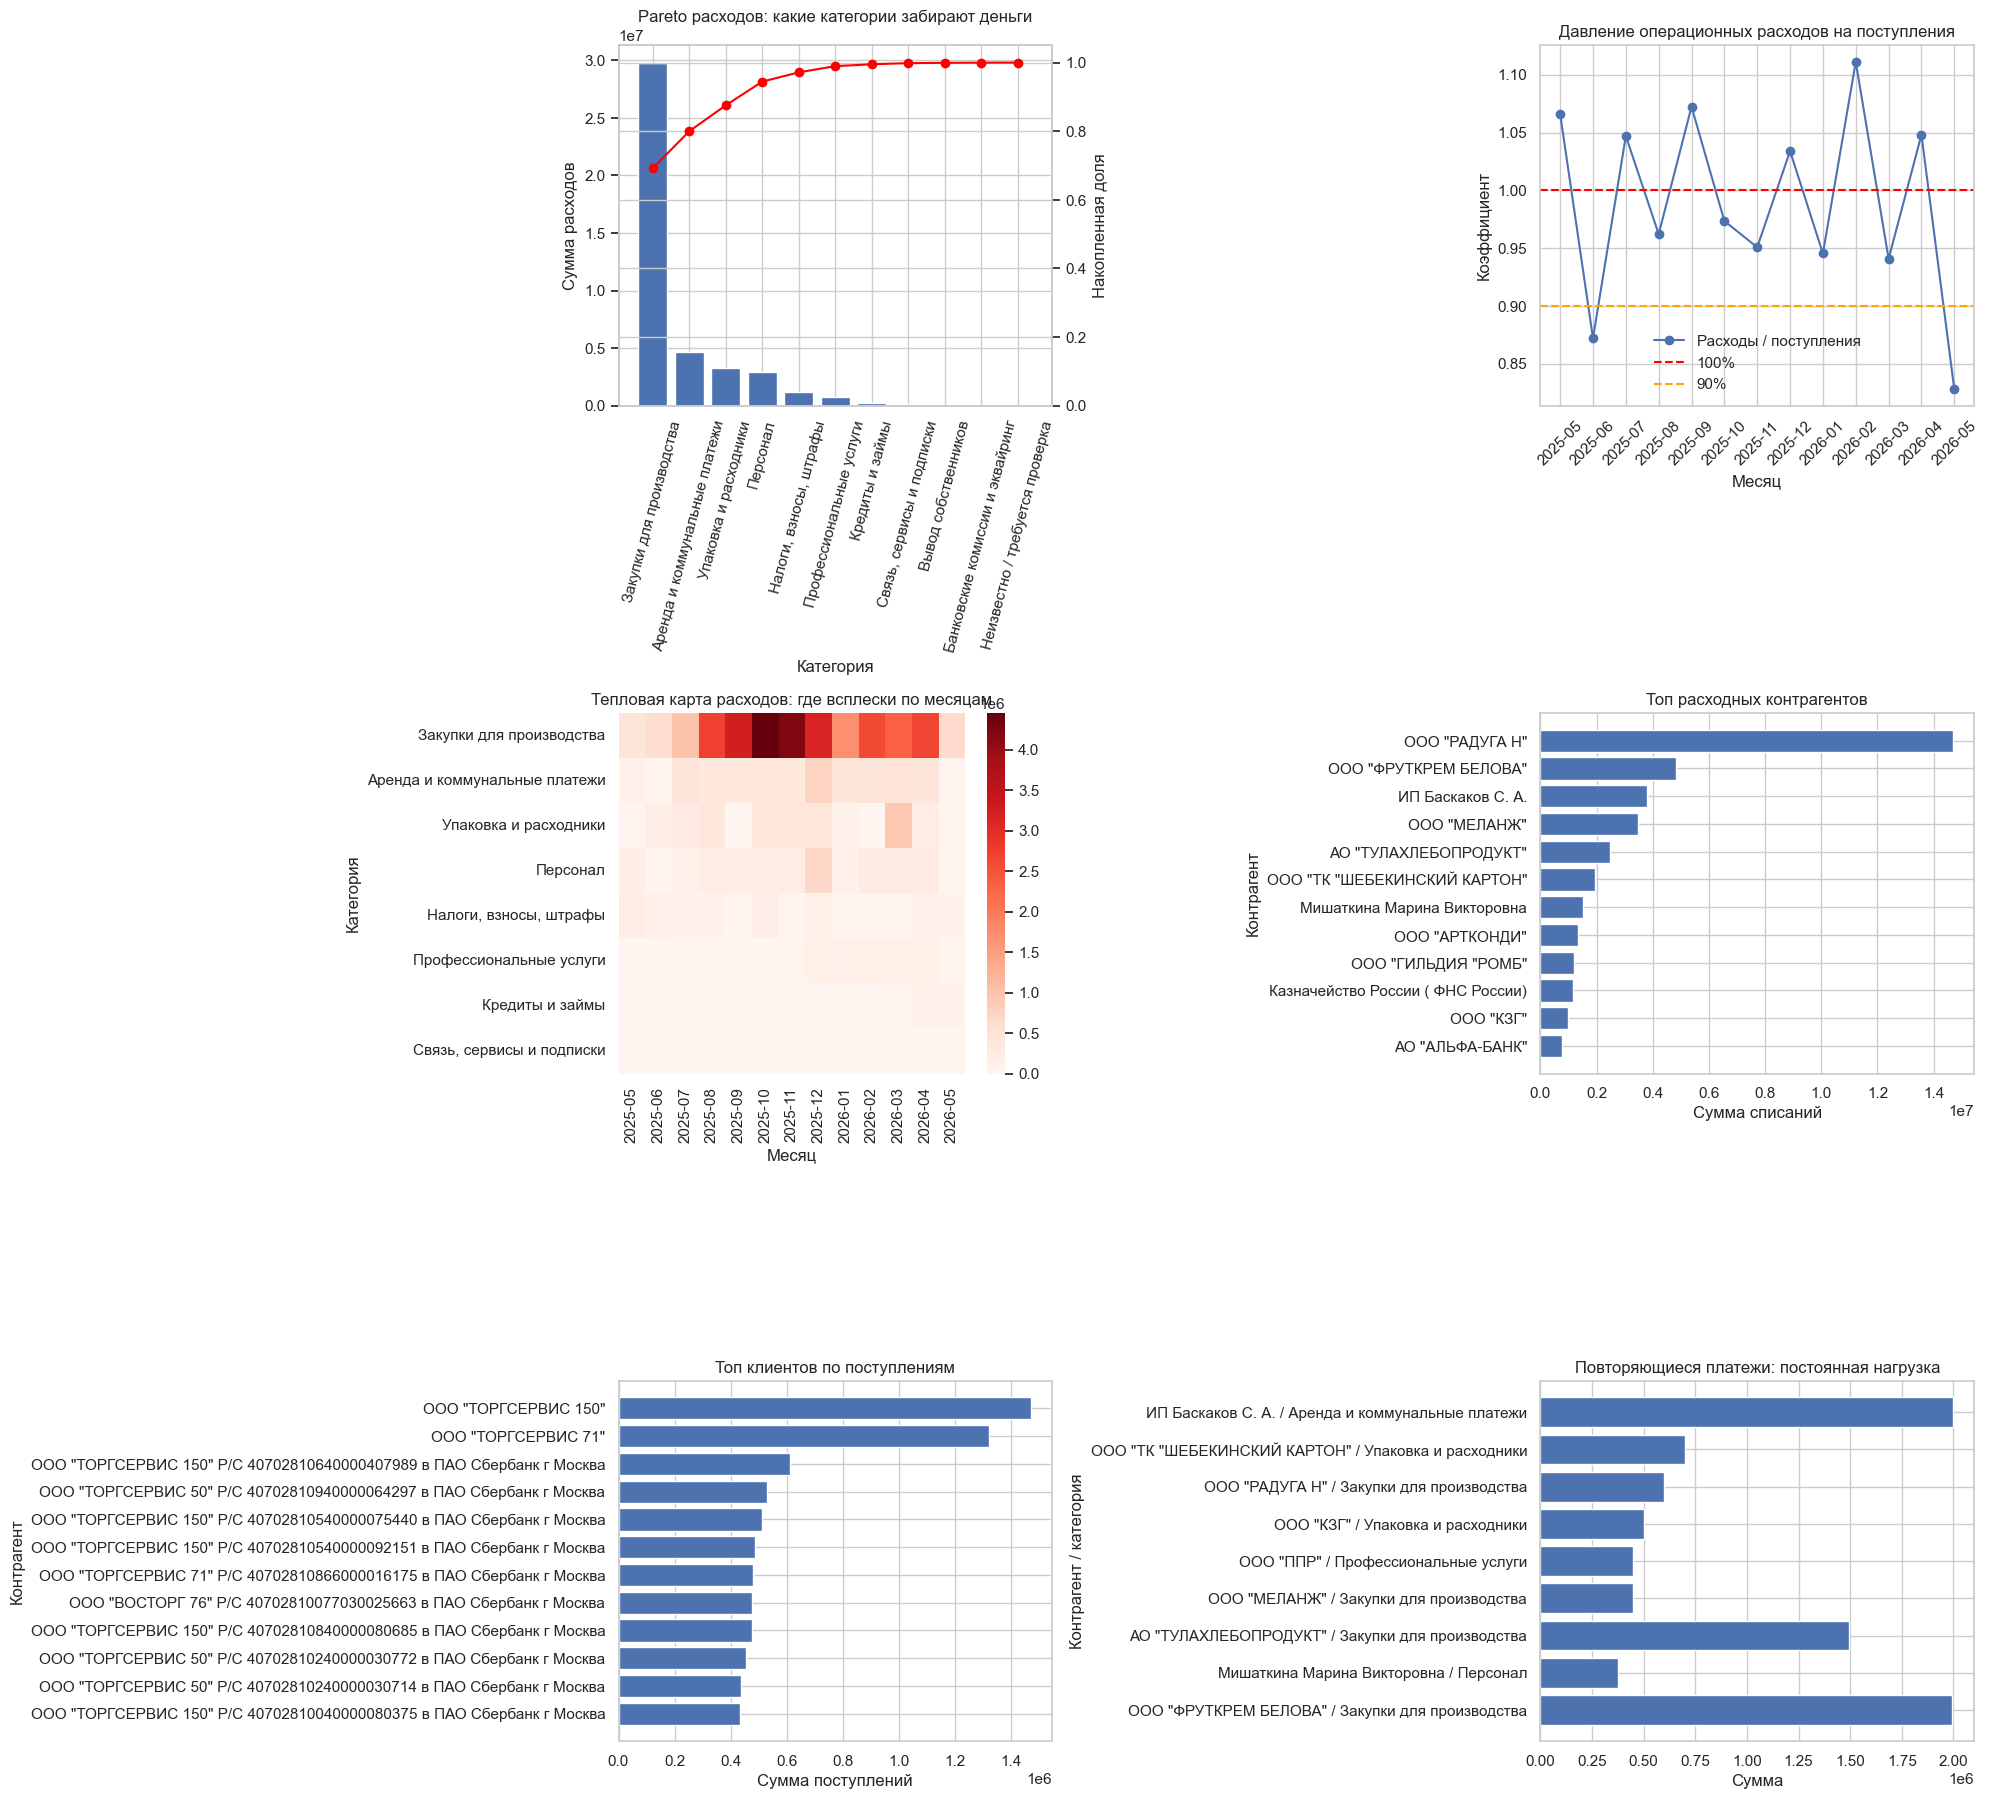

In [184]:

# --- Более содержательные визуализации ---
fig, axes = plt.subplots(3, 2, figsize=(20, 18))

# 1. Pareto расходов по категориям.
pareto_expenses = expense_concentration.sort_values('amount', ascending=False).copy()
pareto_expenses['cumulative_share'] = pareto_expenses['amount'].cumsum() / pareto_expenses['amount'].sum()
axes[0, 0].bar(pareto_expenses['category_final'], pareto_expenses['amount'])
axes[0, 0].set_title('Pareto расходов: какие категории забирают деньги')
axes[0, 0].set_xlabel('Категория')
axes[0, 0].set_ylabel('Сумма расходов')
axes[0, 0].tick_params(axis='x', rotation=75)
ax2 = axes[0, 0].twinx()
ax2.plot(pareto_expenses['category_final'], pareto_expenses['cumulative_share'], color='red', marker='o')
ax2.set_ylabel('Накопленная доля')
ax2.set_ylim(0, 1.05)

# 2. Месячный cash pressure: расходы к поступлениям.
axes[0, 1].plot(cash_pressure['month'], cash_pressure['outflow_to_inflow_ratio'], marker='o', label='Расходы / поступления')
axes[0, 1].axhline(1.0, color='red', linestyle='--', label='100%')
axes[0, 1].axhline(0.9, color='orange', linestyle='--', label='90%')
axes[0, 1].set_title('Давление операционных расходов на поступления')
axes[0, 1].set_xlabel('Месяц')
axes[0, 1].set_ylabel('Коэффициент')
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].legend()

# 3. Heatmap расходов по категориям и месяцам.
heatmap_data = monthly_category_outflows.loc[:, monthly_category_outflows.sum().sort_values(ascending=False).head(8).index]
if sns:
    sns.heatmap(heatmap_data.T, cmap='Reds', ax=axes[1, 0])
else:
    axes[1, 0].imshow(heatmap_data.T, aspect='auto', cmap='Reds')
    axes[1, 0].set_yticks(range(len(heatmap_data.columns)), heatmap_data.columns)
    axes[1, 0].set_xticks(range(len(heatmap_data.index)), heatmap_data.index, rotation=45)
axes[1, 0].set_title('Тепловая карта расходов: где всплески по месяцам')
axes[1, 0].set_xlabel('Месяц')
axes[1, 0].set_ylabel('Категория')

# 4. Топ поставщиков/расходных контрагентов.
top_suppliers_plot = supplier_concentration.head(12).sort_values('amount', ascending=True)
axes[1, 1].barh(top_suppliers_plot['counterparty'], top_suppliers_plot['amount'])
axes[1, 1].set_title('Топ расходных контрагентов')
axes[1, 1].set_xlabel('Сумма списаний')
axes[1, 1].set_ylabel('Контрагент')

# 5. Топ клиентов и концентрация выручки.
top_clients_plot = client_concentration.head(12).sort_values('amount', ascending=True)
axes[2, 0].barh(top_clients_plot['counterparty'], top_clients_plot['amount'])
axes[2, 0].set_title('Топ клиентов по поступлениям')
axes[2, 0].set_xlabel('Сумма поступлений')
axes[2, 0].set_ylabel('Контрагент')

# 6. Повторяющаяся база расходов.
recurring_plot = recurring_payments.head(12).sort_values('total_amount', ascending=True)
labels = recurring_plot['counterparty'].astype(str) + ' / ' + recurring_plot['category_final'].astype(str)
axes[2, 1].barh(labels, recurring_plot['total_amount'])
axes[2, 1].set_title('Повторяющиеся платежи: постоянная нагрузка')
axes[2, 1].set_xlabel('Сумма')
axes[2, 1].set_ylabel('Контрагент / категория')

plt.tight_layout()


In [185]:

# --- Автоматические управленческие выводы ---
top_expense = expense_concentration.iloc[0]
top_supplier = supplier_concentration.iloc[0] if not supplier_concentration.empty else None
top_client = client_concentration.iloc[0] if not client_concentration.empty else None
negative_net_months = cash_pressure.loc[cash_pressure['net_cash_flow_before_internal'].lt(0), 'month'].tolist()
weak_ocf_months = cash_pressure.loc[cash_pressure['ocf_margin'].lt(0.08), 'month'].tolist()
unknown_amount_total = analysis_bank.loc[analysis_bank['category_final'].eq(UNKNOWN_CATEGORY), 'amount'].sum()
unknown_count_total = int(analysis_bank['category_final'].eq(UNKNOWN_CATEGORY).sum())

insight_rows = []
insight_rows.append({
    'insight': 'Unknown почти устранён',
    'evidence': f'{unknown_count_total} операций на {unknown_amount_total:,.0f} руб. ({unknown_amount_total / max(analysis_bank["amount"].sum(), 1):.2%} оборота)',
    'interpretation': 'Классификация стала пригодной для Cash Flow; оставшийся unknown можно проверить вручную.'
})
insight_rows.append({
    'insight': 'Главный денежный расход',
    'evidence': f'{top_expense["category_final"]}: {top_expense["amount"]:,.0f} руб.',
    'interpretation': 'Именно эту категорию надо разбирать по поставщикам, ценам, объёмам и условиям оплаты.'
})
if top_supplier is not None:
    insight_rows.append({
        'insight': 'Концентрация расходного контрагента',
        'evidence': f'{top_supplier["counterparty"]}: {top_supplier["amount"]:,.0f} руб.',
        'interpretation': 'Проверить зависимость от поставщика, отсрочки, авансы и возможность переговоров по условиям.'
    })
if top_client is not None:
    insight_rows.append({
        'insight': 'Концентрация поступлений',
        'evidence': f'{top_client["counterparty"]}: {top_client["amount"]:,.0f} руб.',
        'interpretation': 'Если доля топ-клиентов высока, кассовые разрывы могут идти от задержек оплат нескольких покупателей.'
    })
insight_rows.append({
    'insight': 'Месяцы с отрицательным net cash flow before internal',
    'evidence': ', '.join(negative_net_months) if negative_net_months else 'нет',
    'interpretation': 'Эти месяцы надо смотреть как кассовые провалы: какие категории/контрагенты забрали деньги.'
})
insight_rows.append({
    'insight': 'Месяцы со слабой операционной маржой cash flow',
    'evidence': ', '.join(weak_ocf_months) if weak_ocf_months else 'нет',
    'interpretation': 'Даже положительный OCF может быть слишком тонким, если расходы съедают почти все поступления.'
})
if not recurring_payments.empty:
    top_recurring = recurring_payments.iloc[0]
    insight_rows.append({
        'insight': 'Крупнейшая повторяющаяся нагрузка',
        'evidence': f'{top_recurring["counterparty"]} / {top_recurring["category_final"]}: {top_recurring["total_amount"]:,.0f} руб., {int(top_recurring["operations"])} операций',
        'interpretation': 'Повторяющиеся платежи формируют базу постоянного cash burn; их надо отделять от разовых закупок.'
    })

analytics_insights = pd.DataFrame(insight_rows)

insight_md = ['# Автоматические выводы по Cash Flow и классификации', '']
for _, row in analytics_insights.iterrows():
    insight_md.append(f'## {row["insight"]}')
    insight_md.append(f'- Факт: {row["evidence"]}')
    insight_md.append(f'- Интерпретация: {row["interpretation"]}')
    insight_md.append('')

display(analytics_insights)
print('\n'.join(insight_md))


,insight,evidence,interpretation
0,Unknown почти устранён,"1 операций на 5,793 руб. (0.01% оборота)",Классификация стала пригодной для Cash Flow; оставшийся unknown можно проверить вручную.
1,Главный денежный расход,"Закупки для производства: 29,804,203 руб.","Именно эту категорию надо разбирать по поставщикам, ценам, объёмам и условиям оплаты."
2,Концентрация расходного контрагента,"ООО ""РАДУГА Н"": 14,700,980 руб.","Проверить зависимость от поставщика, отсрочки, авансы и возможность переговоров по условиям."
3,Концентрация поступлений,"ООО ""ТОРГСЕРВИС 150"": 1,473,544 руб.","Если доля топ-клиентов высока, кассовые разрывы могут идти от задержек оплат нескольких покупателей."
4,Месяцы с отрицательным net cash flow before internal,"2025-05, 2025-07, 2025-09, 2025-12, 2026-02, 2026-04",Эти месяцы надо смотреть как кассовые провалы: какие категории/контрагенты забрали деньги.
5,Месяцы со слабой операционной маржой cash flow,"2025-05, 2025-07, 2025-08, 2025-09, 2025-10, 2025-11, 2025-12, 2026-01, 2026-02, 2026-03, 2026-04","Даже положительный OCF может быть слишком тонким, если расходы съедают почти все поступления."
6,Крупнейшая повторяющаяся нагрузка,"ИП Баскаков С. А. / Аренда и коммунальные платежи: 1,999,620 руб., 9 операций",Повторяющиеся платежи формируют базу постоянного cash burn; их надо отделять от разовых закупок.


# Автоматические выводы по Cash Flow и классификации

## Unknown почти устранён
- Факт: 1 операций на 5,793 руб. (0.01% оборота)
- Интерпретация: Классификация стала пригодной для Cash Flow; оставшийся unknown можно проверить вручную.

## Главный денежный расход
- Факт: Закупки для производства: 29,804,203 руб.
- Интерпретация: Именно эту категорию надо разбирать по поставщикам, ценам, объёмам и условиям оплаты.

## Концентрация расходного контрагента
- Факт: ООО "РАДУГА Н": 14,700,980 руб.
- Интерпретация: Проверить зависимость от поставщика, отсрочки, авансы и возможность переговоров по условиям.

## Концентрация поступлений
- Факт: ООО "ТОРГСЕРВИС 150": 1,473,544 руб.
- Интерпретация: Если доля топ-клиентов высока, кассовые разрывы могут идти от задержек оплат нескольких покупателей.

## Месяцы с отрицательным net cash flow before internal
- Факт: 2025-05, 2025-07, 2025-09, 2025-12, 2026-02, 2026-04
- Интерпретация: Эти месяцы надо смотреть как кассовые провалы: какие категории/конт

## Сохранение итоговых таблиц

In [ ]:
cleaned_columns = [
    'operation_id', 'date', 'month', 'operation_type', 'amount', 'signed_amount',
    'counterparty', 'description', 'raw_credit', 'raw_debit', 'raw_date', 'date_parse_source'
]
classified_columns = cleaned_columns + [
    'category_rule', 'subcategory_rule', 'rule_confidence', 'rule_reason',
    'category_llm', 'subcategory_llm', 'llm_confidence', 'llm_reason', 'llm_error',
    'category_final', 'subcategory_final', 'category_group', 'category_source',
    'category_confidence', 'needs_review', 'review_reason', 'cash_flow_section'
]

print('Готовая очищенная таблица:', bank[cleaned_columns].shape)
print('Готовая классифицированная таблица:', bank[classified_columns].shape)
display(bank[cleaned_columns].head())
display(bank[classified_columns].head())


Сохранено в: /Users/pavelesipenok/Documents/New project/Исследование разметки транзакций/outputs
- /Users/pavelesipenok/Documents/New project/Исследование разметки транзакций/outputs/cleaned_bank_operations.csv
- /Users/pavelesipenok/Documents/New project/Исследование разметки транзакций/outputs/classified_bank_operations.csv
- /Users/pavelesipenok/Documents/New project/Исследование разметки транзакций/outputs/cash_flow_by_month.csv
- /Users/pavelesipenok/Documents/New project/Исследование разметки транзакций/outputs/category_summary.csv
- /Users/pavelesipenok/Documents/New project/Исследование разметки транзакций/outputs/manual_validation_500.csv
- /Users/pavelesipenok/Documents/New project/Исследование разметки транзакций/outputs/manual_validation_500.xlsx
- /Users/pavelesipenok/Documents/New project/Исследование разметки транзакций/outputs/rows_with_missing_dates.csv
- /Users/pavelesipenok/Documents/New project/Исследование разметки транзакций/outputs/classification_disagreements.cs

## Финальные выводы

In [ ]:
total_credit = bank.loc[bank['operation_type'].eq('credit'), 'amount'].sum()
total_debit = bank.loc[bank['operation_type'].eq('debit'), 'amount'].sum()
unknown_mask = bank['category_final'].eq(UNKNOWN_CATEGORY)
negative_ocf_months = cash_flow_by_month.loc[cash_flow_by_month['operating_cash_flow'].lt(0), 'month'].tolist()

largest_expenses = (
    bank.loc[bank['operation_type'].eq('debit')]
    .groupby('category_final')['amount'].sum()
    .sort_values(ascending=False)
    .head(5)
)
largest_inflows = (
    bank.loc[bank['operation_type'].eq('credit')]
    .groupby('category_final')['amount'].sum()
    .sort_values(ascending=False)
    .head(5)
)
conflict_summary = (
    classification_disagreements.groupby(['category_rule', 'category_llm']).size().sort_values(ascending=False).head(10)
    if not classification_disagreements.empty else pd.Series(dtype=int)
)

final_summary = {
    'Всего операций': len(bank),
    'Сумма credit': total_credit,
    'Сумма debit': total_debit,
    'Период анализа': f"{bank['date'].min()} — {bank['date'].max()}",
    'Классифицировано автоматически': int((~bank['needs_review']).sum()),
    'Требует ручной проверки': int(bank['needs_review'].sum()),
    'Доля unknown по количеству': float(unknown_mask.mean()),
    'Доля unknown по сумме': float(bank.loc[unknown_mask, 'amount'].sum() / max(bank['amount'].sum(), 1)),
    'Доля операций без даты': float(bank['date'].isna().mean()),
    'Сумма операций без даты': float(bank.loc[bank['date'].isna(), 'amount'].sum()),
    'Месяцы с отрицательным OCF': ', '.join(negative_ocf_months) if negative_ocf_months else 'нет',
    'Сумма по кредитам и займам': float(bank.loc[bank['category_final'].eq('Кредиты и займы'), 'amount'].sum()),
    'Сумма выводов собственников': float(bank.loc[bank['category_final'].eq('Вывод собственников'), 'amount'].sum()),
    'Сумма внутренних переводов': float(bank.loc[bank['category_final'].eq('Внутренние переводы'), 'amount'].sum()),
}

display(pd.DataFrame(final_summary.items(), columns=['Показатель', 'Значение']))
print('\nКрупнейшие категории расходов:')
display(largest_expenses.reset_index(name='amount'))
print('\nКрупнейшие категории поступлений:')
display(largest_inflows.reset_index(name='amount'))
print('\nЧастые конфликты rule vs LLM:')
display(conflict_summary.reset_index(name='count') if not conflict_summary.empty else pd.DataFrame({'message': ['LLM не запускалась или конфликтов нет']}))

print('\nИнтерпретация:')
if negative_ocf_months:
    print(f'- В {len(negative_ocf_months)} месяцах операционный денежный поток отрицательный: бизнес в эти месяцы тратит на операционку больше, чем получает от клиентов и прочих поступлений.')
if not largest_expenses.empty:
    print(f'- Главная расходная категория: {largest_expenses.index[0]} на сумму {largest_expenses.iloc[0]:,.0f}.')
if bank['needs_review'].mean() > 0.2:
    print('- Существенная доля операций требует ручной проверки: перед управленческими выводами нужно подтвердить спорные категории.')
if bank.loc[unknown_mask, 'amount'].sum() > 0:
    print('- Unknown-операции вынесены отдельно, чтобы не искажать Cash Flow.')
if final_summary['Сумма по кредитам и займам'] > 0:
    print('- Кредиты и займы нужно анализировать отдельно от операционной прибыльности: они могут объяснять, почему деньги не остаются в бизнесе.')
if final_summary['Сумма внутренних переводов'] > 0:
    print('- Внутренние переводы исключены из net cash flow before internal, чтобы не завышать обороты.')
print('- Для финальной валидации заполните manual_validation_500.xlsx и сохраните копию как manual_validation_500_labeled.xlsx.')


,Показатель,Значение
0,Всего операций,4190
1,Сумма credit,"42,980,552.55"
2,Сумма debit,"43,058,343.85"
3,Период анализа,2025-05-01 00:00:00 — 2026-05-08 00:00:00
4,Классифицировано автоматически,3945
5,Требует ручной проверки,245
6,Доля unknown по количеству,0.00
7,Доля unknown по сумме,0.00
8,Доля операций без даты,0.00
9,Сумма операций без даты,0.00



Крупнейшие категории расходов:


,category_final,amount
0,Закупки для производства,"29,804,202.60"
1,Аренда и коммунальные платежи,"4,642,628.93"
2,Упаковка и расходники,"3,252,205.74"
3,Персонал,"2,971,955.00"
4,"Налоги, взносы, штрафы","1,156,005.00"



Крупнейшие категории поступлений:


,category_final,amount
0,Выручка от клиентов,"42,972,933.55"
1,Возвраты,"7,619.00"



Частые конфликты rule vs LLM:


,message
0,LLM не запускалась или конфликтов нет



Интерпретация:
- В 6 месяцах операционный денежный поток отрицательный: бизнес в эти месяцы тратит на операционку больше, чем получает от клиентов и прочих поступлений.
- Главная расходная категория: Закупки для производства на сумму 29,804,203.
- Unknown-операции вынесены отдельно, чтобы не искажать Cash Flow.
- Кредиты и займы нужно анализировать отдельно от операционной прибыльности: они могут объяснять, почему деньги не остаются в бизнесе.
- Для финальной валидации заполните manual_validation_500.xlsx и сохраните копию как manual_validation_500_labeled.xlsx.
